In [41]:
%load_ext autoreload
%autoreload 2

import jax 
jax.config.update('jax_enable_checks', False)
import sys
import os
# import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from typing import NamedTuple, Tuple, Dict, List
import jax.experimental.checkify as checkify # Import checkify
from hydra import initialize, compose
from omegaconf import DictConfig, OmegaConf
from jax import config
import chex
config.update("jax_enable_x64", True)

import matplotlib.pyplot as plt
import matplotlib as mpl
import jax.random as jr


# IMPORTANT: Set this to the correct root directory of your project
# Use an absolute path for reliability
root_dir = r"c:\Users\jimvo\Documents\Recurrent-PPO-Jax" # Use the path you provided

if not os.path.isdir(root_dir):
    print(f"Error: Directory not found: {root_dir}")
    print("Please update the 'root_dir' variable to the correct path.")
else:
    if root_dir not in sys.path:
        sys.path.append(root_dir)
        print(f"Added {root_dir} to sys.path")

# Attempt to import your sampler functions
try:
    
    from src.agents.ppo_dic_inherits.inh_agents.flow_full import FlowGaussian
    from src.agents.ppo_dic_inherits.inh_agents.norm_flow_agent import NormFlowAgent 
    
    from src.gp.gpjax import BayesianOptimizer, BOState, BOStaticParams, calculate_ucb

    
   
except ImportError as e:
    print(f"Error importing functions: {e}")
    print("Please ensure 'root_dir' is correct and the module path exists:")
    print("src.tasks.envs.function_envs.jax_samplers.jax_function_samplers")
except Exception as e:
    print(f"An unexpected error occurred during import: {e}")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


--- Testing FlowGaussian ---

FlowGaussian 1D (Standard-like: mean=0.0, scale=0.2)
gaussian_log_prob (300, 1, 1) (300, 2) None
means_all (300, 1, 1) scales_all (300, 1, 1) clipped_actions (300, 1, 1)
eeeeyo shape: (300, 1, 1), act_logits shape: (300, 2) (300,)
Sampled 5000 points for histogram. First 5: [ 0.13993033 -0.36193044 -0.21026814  0.03842665 -0.00500105]


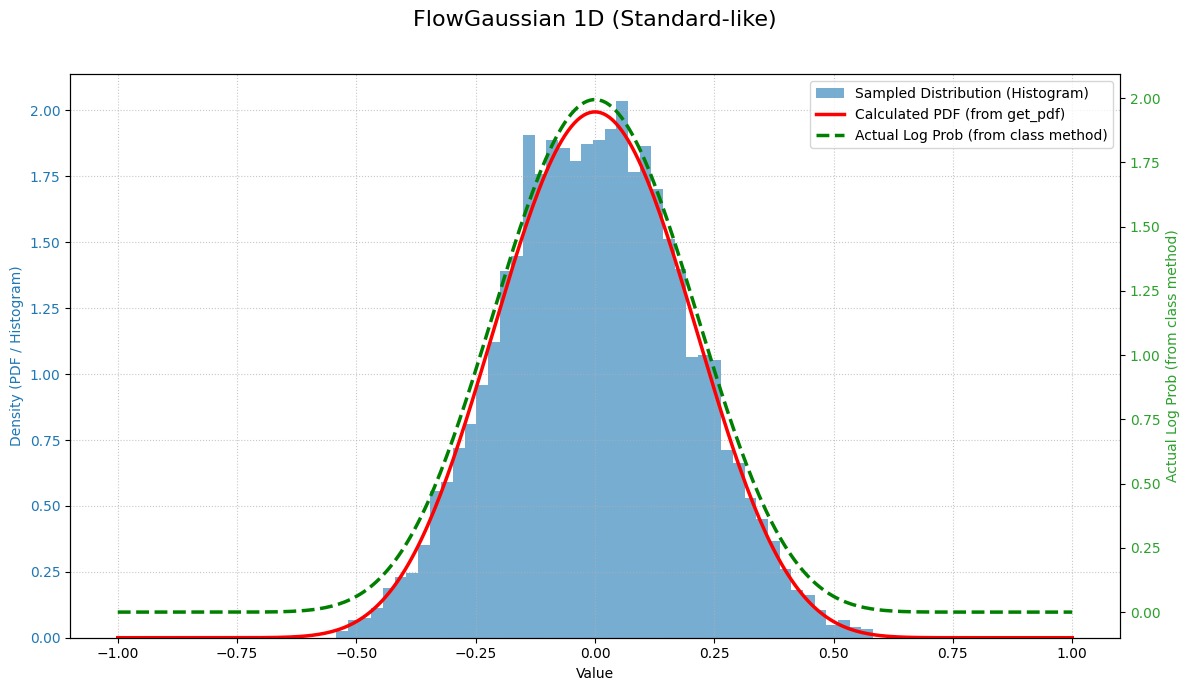

ations (5, 1, 1) act_logits (5, 2) (5000, 1)
gaussian_log_prob (5, 1, 1) (5, 2) None
means_all (5, 1, 1) scales_all (5, 1, 1) clipped_actions (5, 1, 1)
Log probabilities for first 5 samples (using gaussian_log_prob): [ 0.46227418 -0.96560852  0.16619795  0.67350129  0.69021175]
Entropy (MC): -0.24521364203895807

FlowGaussian 1D (Random: mean=0.77, scale=0.74)
gaussian_log_prob (300, 1, 1) (300, 2) None
means_all (300, 1, 1) scales_all (300, 1, 1) clipped_actions (300, 1, 1)


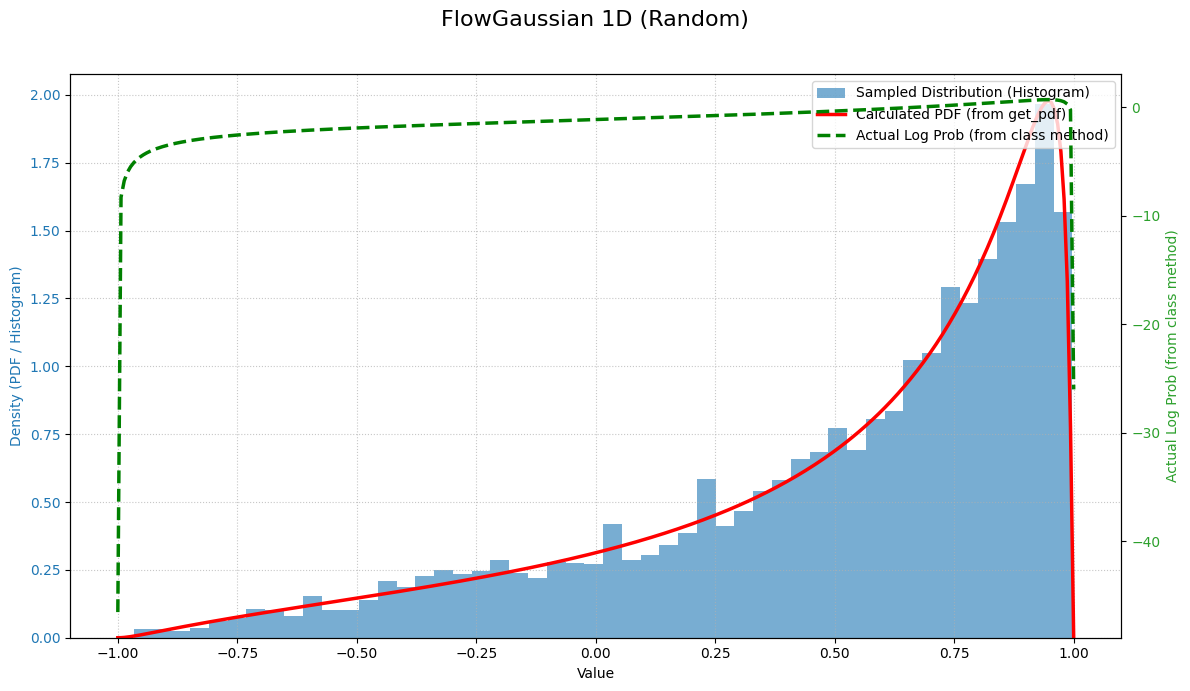


FlowGaussian 2D (Random: means=[[-0.42152244 -0.44515813]], scales=[[0.48939181 1.43533701]])


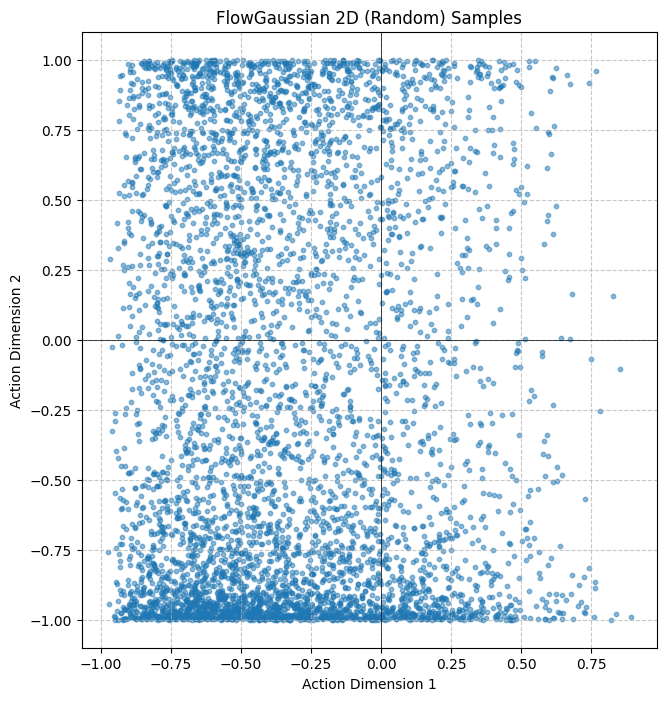

gaussian_log_prob (1, 1, 2) (1, 4) None
means_all (1, 1, 2) scales_all (1, 1, 2) clipped_actions (1, 1, 2)
Log probability for one 2D sample (using gaussian_log_prob): [-1.8767148]
Entropy (MC) for 2D distribution: 0.9016389218042692


--- Testing NormFlowAgent ---
sg ()
sg ()

NormFlowAgent 1D (Standard-like: loc=[0.], raw_L00 to target L00_processed=1.0 is 0.10)
Sampled 5000 points. First 5: [-0.1324508   0.07637743 -0.14999744 -0.01025544  0.07113684]
eeeeyo shape: (300, 1, 1), act_logits shape: (300, 2) (300,)


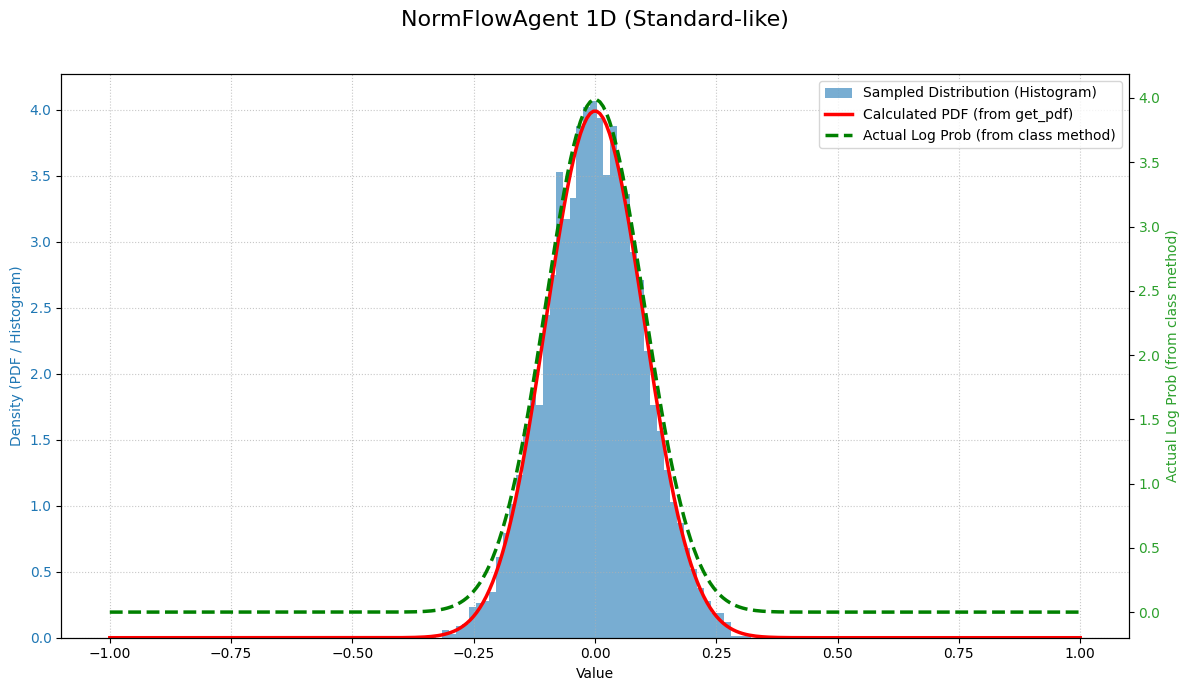

Log probability for first 1 sample(s) (using gaussian_log_prob): [0.51378601]
Entropy (MC): -0.704462632367783

NormFlowAgent 1D (Random: loc=[-0.15299808], raw_tril_diag_input=[0.23054457])


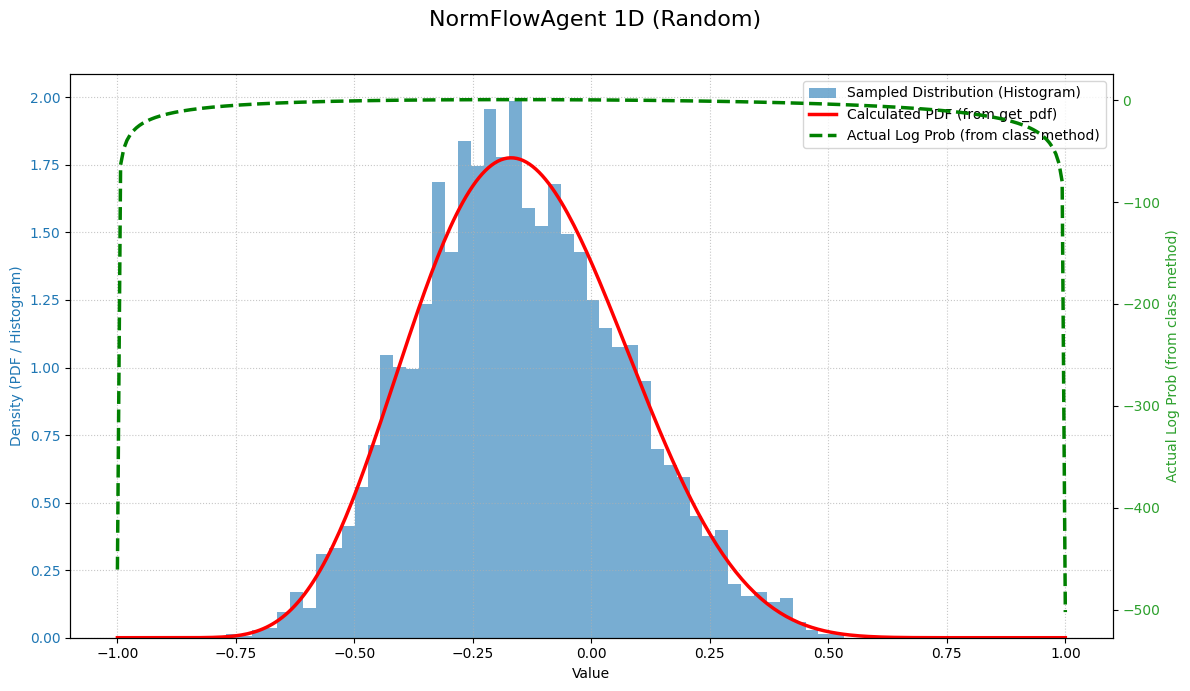


NormFlowAgent 2D (Random: loc=[0.46339453 0.35482089], raw_tril_values_input=[-0.4706658   0.29408416 -0.28168617])


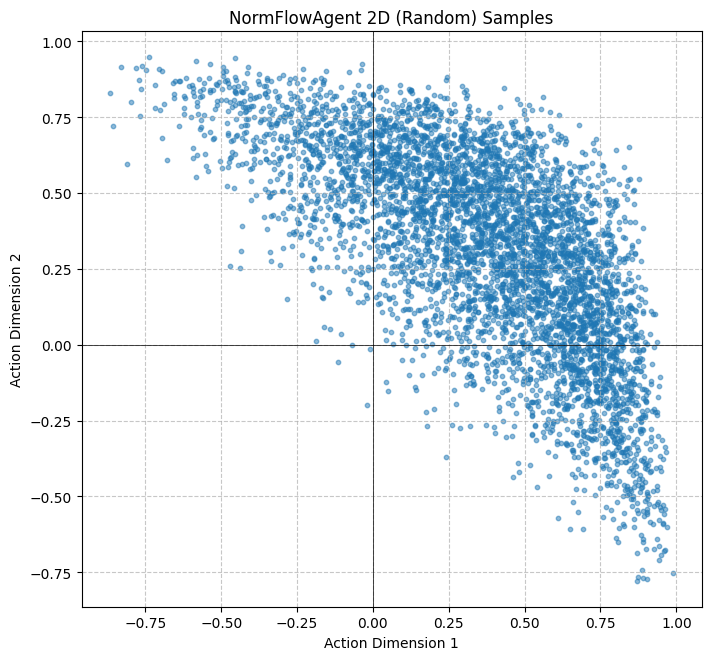

Log probability for one 2D sample (using gaussian_log_prob): [0.4886016]
Entropy (MC) for 2D distribution: -0.035784568499187284


Final Note: Visual check of PDF vs samples and the shape of 'Actual Log Prob (from class method)' is key.


In [44]:
EPSILON = 1e-6

def plot_samples_vs_pdf(samples, pdf_values, x_range, title, bins=50, 
                        actual_log_prob_values=None, actual_log_prob_label="Actual Log Prob (from class method)"):
    """
    Plots histogram of samples, PDF curve, and optionally 
    actual log_prob values (from the class's gaussian_log_prob method) on a second y-axis.
    """
    fig, ax1 = plt.subplots(figsize=(12, 7))

    # Plot histogram on ax1
    ax1.hist(samples.flatten(), bins=bins, density=True, alpha=0.6, label='Sampled Distribution (Histogram)', color='tab:blue')
    ax1.set_xlabel('Value')
    ax1.set_ylabel('Density (PDF / Histogram)', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')

    # Plot PDF on ax1
    if pdf_values is not None and x_range is not None:
        ax1.plot(x_range, pdf_values, color='red', lw=2.5, label='Calculated PDF (from get_pdf)')
    
    handles1, labels1 = ax1.get_legend_handles_labels()

    # Plot actual_log_prob_values on ax2 (secondary y-axis)
    if actual_log_prob_values is not None and x_range is not None:
        ax2 = ax1.twinx() 
        # Normalize log_prob_values for better visualization if their scale is too different,
        # or plot as is if the user wants to see the raw scale. For now, plot as is.
        ax2.plot(x_range, actual_log_prob_values, color='green', linestyle='--', lw=2.5, label=actual_log_prob_label)
        ax2.set_ylabel(actual_log_prob_label, color='tab:green')
        ax2.tick_params(axis='y', labelcolor='tab:green')
        handles2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(handles1 + handles2, labels1 + labels2, loc='upper right')
    else:
        ax1.legend(handles1, labels1, loc='upper right')
        
    fig.suptitle(title, fontsize=16)
    ax1.grid(True, linestyle=':', alpha=0.7)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


def plot_samples_2d(samples, title):
    """Plots a 2D scatter plot of samples."""
    if samples.shape[1] != 2:
        print("Can only plot 2D samples for this function.")
        if samples.shape[1] == 1:
             plt.hist(samples.flatten(), bins=50, density=True, alpha=0.7, label='Dim 1')
             plt.title(f"{title} - Marginal Dim 1")
             plt.show()
        return
    plt.figure(figsize=(8, 8))
    plt.scatter(samples[:, 0], samples[:, 1], alpha=0.5, s=10)
    plt.title(title)
    plt.xlabel('Action Dimension 1')
    plt.ylabel('Action Dimension 2')
    plt.axhline(0, color='black', lw=0.5)
    plt.axvline(0, color='black', lw=0.5)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.show()

#-------------------------------------------------------------------------------
# Test Configuration
#-------------------------------------------------------------------------------
num_samples_for_hist = 5000
x_eval_points_flat = jnp.linspace(-1 + EPSILON, 1 - EPSILON, 300) # Flat for easy use
x_eval_points_reshaped = x_eval_points_flat[:, None] # Shape (300,1) for PDF/LogProb methods

#-------------------------------------------------------------------------------
# Testing FlowGaussian (assuming FlowGaussian is not None due to successful import)
#-------------------------------------------------------------------------------
if FlowGaussian is not None:
    print("--- Testing FlowGaussian ---")

    # --- Test Case 1: FlowGaussian, 1D, Standard-like parameters ---
    key, fg_key_s1, fg_key_lp1_curve, fg_key_lp1_pts, fg_key_e1 = jax.random.split(key, 5)
    action_dim_fg1 = 1

    std_mean_fg1 = 0.0
    std_scale_fg1 = 0.2 
    act_logits_fg1_single_dist_params = jnp.array([std_mean_fg1, std_scale_fg1])

    print(f"\nFlowGaussian 1D (Standard-like: mean={std_mean_fg1}, scale={std_scale_fg1})")

    # Agent for PDF and single log_prob curve (FlowGaussian self.batch_size = 1)
    fg_agent_b1_ad1 = FlowGaussian(1, action_dim_fg1) 
    
    # PDF values from get_pdf
    pdf_values_fg1_std_batch = fg_agent_b1_ad1.get_pdf(act_logits_fg1_single_dist_params, None, x_eval_points_reshaped)
    pdf_values_fg1_std = pdf_values_fg1_std_batch[0]

    # Actual Log Prob values from gaussian_log_prob for the curve
    # `actions` shape: (N_eval_points, agent_batch_size, action_dim) -> (300, 1, 1)
    actions_for_log_prob_curve_fg1 = x_eval_points_reshaped.reshape(x_eval_points_reshaped.shape[0], 1, action_dim_fg1)
    # `act_logits` shape: (N_eval_points, 2 * agent_batch_size * action_dim) -> (300, 2*1*1=2)
    # Tile the single dist params for each eval point
    act_logits_for_log_prob_curve_fg1 = jnp.tile(act_logits_fg1_single_dist_params, (x_eval_points_reshaped.shape[0], 1))
    
    
    
    actual_log_probs_curve_fg1_std = fg_agent_b1_ad1.gaussian_log_prob(actions_for_log_prob_curve_fg1, act_logits_for_log_prob_curve_fg1, None)
    
    print(f"eeeeyo shape: {actions_for_log_prob_curve_fg1.shape}, act_logits shape: {act_logits_for_log_prob_curve_fg1.shape}", actual_log_probs_curve_fg1_std.shape)
    
    actual_log_probs_curve_fg1_std = jnp.exp(actual_log_probs_curve_fg1_std)  # Convert log probs to probabilities

    # Agent and logits for sampling num_samples_for_hist
    fg_agent_bHist_ad1 = FlowGaussian(num_samples_for_hist, action_dim_fg1)
    act_logits_fg1_std_means_hist = jnp.full((num_samples_for_hist, action_dim_fg1), std_mean_fg1)
    act_logits_fg1_std_scales_hist = jnp.full((num_samples_for_hist, action_dim_fg1), std_scale_fg1)
    act_logits_fg1_std_for_hist = jnp.concatenate([act_logits_fg1_std_means_hist.flatten(), act_logits_fg1_std_scales_hist.flatten()])
    samples_fg1_std = fg_agent_bHist_ad1.sampling_differ(act_logits_fg1_std_for_hist, None, fg_key_s1, masks=jnp.array([num_samples_for_hist]))
    print(f"Sampled {samples_fg1_std.shape[0]} points for histogram. First 5: {samples_fg1_std[:5].flatten()}")

    plot_samples_vs_pdf(samples_fg1_std, pdf_values_fg1_std, x_eval_points_flat, 
                        "FlowGaussian 1D (Standard-like)", 
                        actual_log_prob_values=actual_log_probs_curve_fg1_std)

    # Log Prob test for a few specific points using the single distribution definition
    num_test_points_fg1 = min(5, samples_fg1_std.shape[0])
    if num_test_points_fg1 > 0:
        # actions: (num_test_points, agent_batch_size=1, action_dim=1)
        test_actions_pts_fg1 = samples_fg1_std[:num_test_points_fg1].reshape(num_test_points_fg1, 1, action_dim_fg1)
        # act_logits: (num_test_points, 2 * agent_batch_size=1 * action_dim=1)
        act_logits_pts_fg1 = jnp.tile(act_logits_fg1_single_dist_params, (num_test_points_fg1, 1))
        
        print("ations", test_actions_pts_fg1.shape, "act_logits", act_logits_pts_fg1.shape, samples_fg1_std.shape)
        
        log_probs_pts_fg1_std = fg_agent_b1_ad1.gaussian_log_prob(test_actions_pts_fg1, act_logits_pts_fg1, None)
        print(f"Log probabilities for first {num_test_points_fg1} samples (using gaussian_log_prob): {log_probs_pts_fg1_std}")
    else:
        print("Not enough samples to test point log probabilities for FlowGaussian std.")

    # Entropy test (N=1, agent_batch_size=1)
    act_logits_entropy_fg1 = act_logits_fg1_single_dist_params.reshape(1, -1) # N=1
    mask_entropy_fg1 = jnp.array([[1.0]]) # N=1
    entropy_fg1_std = fg_agent_b1_ad1.entropy(act_logits_entropy_fg1, mask_entropy_fg1, None, fg_key_e1)
    print(f"Entropy (MC): {entropy_fg1_std.item()}")


    # --- Test Case 2: FlowGaussian, 1D, Random parameters ---
    key, fg_key_rand_m, fg_key_rand_s, fg_key_rand_samp, fg_key_rand_lp_curve = jax.random.split(key, 5)
    rand_mean_fg1 = jax.random.uniform(fg_key_rand_m, minval=-1.5, maxval=1.5)
    rand_scale_fg1 = jax.random.uniform(fg_key_rand_s, minval=0.2, maxval=1.5) 
    act_logits_fg1_rand_single_dist_params = jnp.array([rand_mean_fg1.item(), rand_scale_fg1.item()])

    print(f"\nFlowGaussian 1D (Random: mean={rand_mean_fg1.item():.2f}, scale={rand_scale_fg1.item():.2f})")

    pdf_values_fg1_rand_batch = fg_agent_b1_ad1.get_pdf(act_logits_fg1_rand_single_dist_params, None, x_eval_points_reshaped)
    pdf_values_fg1_rand = pdf_values_fg1_rand_batch[0]
    
    actions_for_log_prob_curve_fg1_rand = x_eval_points_reshaped.reshape(x_eval_points_reshaped.shape[0], 1, action_dim_fg1)
    act_logits_for_log_prob_curve_fg1_rand = jnp.tile(act_logits_fg1_rand_single_dist_params, (x_eval_points_reshaped.shape[0], 1))
    actual_log_probs_curve_fg1_rand = fg_agent_b1_ad1.gaussian_log_prob(actions_for_log_prob_curve_fg1_rand, act_logits_for_log_prob_curve_fg1_rand, None)

    act_logits_fg1_rand_means_hist = jnp.full((num_samples_for_hist, action_dim_fg1), rand_mean_fg1.item())
    act_logits_fg1_rand_scales_hist = jnp.full((num_samples_for_hist, action_dim_fg1), rand_scale_fg1.item())
    act_logits_fg1_rand_for_hist = jnp.concatenate([act_logits_fg1_rand_means_hist.flatten(), act_logits_fg1_rand_scales_hist.flatten()])
    samples_fg1_rand = fg_agent_bHist_ad1.sampling_differ(act_logits_fg1_rand_for_hist, None, fg_key_rand_samp, masks=jnp.array([num_samples_for_hist]))

    plot_samples_vs_pdf(samples_fg1_rand, pdf_values_fg1_rand, x_eval_points_flat, 
                        "FlowGaussian 1D (Random)",
                        actual_log_prob_values=actual_log_probs_curve_fg1_rand)

    # --- Test Case 3: FlowGaussian, 2D, Random parameters ---
    key, fg_key_2d_m, fg_key_2d_s, fg_key_2d_samp, fg_key_2d_lp_pts, fg_key_2d_e = jax.random.split(key, 6)
    action_dim_fg2 = 2

    means_fg2_rand_single = jax.random.uniform(fg_key_2d_m, shape=(1, action_dim_fg2), minval=-1.0, maxval=1.0)
    scales_fg2_rand_single = jax.random.uniform(fg_key_2d_s, shape=(1, action_dim_fg2), minval=0.2, maxval=1.5)
    act_logits_fg2_single_dist_params = jnp.concatenate([means_fg2_rand_single.flatten(), scales_fg2_rand_single.flatten()])

    print(f"\nFlowGaussian 2D (Random: means={means_fg2_rand_single}, scales={scales_fg2_rand_single})")

    fg_agent_bHist_ad2 = FlowGaussian(num_samples_for_hist, action_dim_fg2)
    act_logits_fg2_rand_means_hist = jnp.tile(means_fg2_rand_single, (num_samples_for_hist, 1))
    act_logits_fg2_rand_scales_hist = jnp.tile(scales_fg2_rand_single, (num_samples_for_hist, 1))
    act_logits_fg2_rand_for_hist = jnp.concatenate([act_logits_fg2_rand_means_hist.flatten(), act_logits_fg2_rand_scales_hist.flatten()])
    samples_fg2_rand = fg_agent_bHist_ad2.sampling_differ(act_logits_fg2_rand_for_hist, None, fg_key_2d_samp, masks=jnp.array([num_samples_for_hist]))
    plot_samples_2d(samples_fg2_rand, "FlowGaussian 2D (Random) Samples")

    fg_agent_b1_ad2 = FlowGaussian(1, action_dim_fg2) 
    num_test_points_fg2 = min(1, samples_fg2_rand.shape[0]) # Test log_prob for one sample
    if num_test_points_fg2 > 0:
        # actions: (num_test_points=1, agent_batch_size=1, action_dim=2)
        test_actions_pts_fg2 = samples_fg2_rand[:num_test_points_fg2].reshape(num_test_points_fg2, 1, action_dim_fg2)
        # act_logits: (num_test_points=1, 2 * agent_batch_size=1 * action_dim=2)
        act_logits_pts_fg2 = jnp.tile(act_logits_fg2_single_dist_params, (num_test_points_fg2, 1))
        log_probs_pts_fg2_rand = fg_agent_b1_ad2.gaussian_log_prob(test_actions_pts_fg2, act_logits_pts_fg2, None)
        print(f"Log probability for one 2D sample (using gaussian_log_prob): {log_probs_pts_fg2_rand}")
    
    act_logits_entropy_fg2 = act_logits_fg2_single_dist_params.reshape(1, -1) # N=1
    mask_entropy_fg2 = jnp.array([[1.0]]) # N=1
    entropy_fg2_rand = fg_agent_b1_ad2.entropy(act_logits_entropy_fg2, mask_entropy_fg2, None, fg_key_2d_e)
    print(f"Entropy (MC) for 2D distribution: {entropy_fg2_rand.item()}")

else:
    print("FlowGaussian class not imported/defined. Skipping FlowGaussian tests.")


#-------------------------------------------------------------------------------
# Testing NormFlowAgent (assuming NormFlowAgent is not None due to successful import)
#-------------------------------------------------------------------------------
if NormFlowAgent is not None:
    print("\n\n--- Testing NormFlowAgent ---")

    # --- Test Case 1: NormFlowAgent, 1D, Standard-like parameters ---
    key, nfa_key_s1, nfa_key_lp1_curve, nfa_key_lp1_pts, nfa_key_e1 = jax.random.split(key, 5)
    action_dim_nfa1 = 1
    nfa_agent_ad1 = NormFlowAgent(num_samples_for_hist, action_dim_nfa1) 

    std_loc_nfa1 = jnp.array([0.0])
    std_raw_L00_nfa1 = jnp.log(jnp.exp(1.0 - 1e-4) - 1) 
    print("sg", std_raw_L00_nfa1.shape)
    std_raw_L00_nfa1 = jnp.array(0.1)
    print("sg", std_raw_L00_nfa1.shape)
    
    act_logits_nfa1_single_dist_params = jnp.concatenate([std_loc_nfa1, jnp.array([std_raw_L00_nfa1])])

    print(f"\nNormFlowAgent 1D (Standard-like: loc={std_loc_nfa1}, raw_L00 to target L00_processed=1.0 is {std_raw_L00_nfa1:.2f})")
    samples_nfa1_std = nfa_agent_ad1.sampling_differ(act_logits_nfa1_single_dist_params, None, nfa_key_s1, mask_threshold_array=jnp.array([num_samples_for_hist]))
    print(f"Sampled {samples_nfa1_std.shape[0]} points. First 5: {samples_nfa1_std[:5].flatten()}")

    pdf_values_nfa1_std = nfa_agent_ad1.get_pdf(act_logits_nfa1_single_dist_params, None, x_eval_points_reshaped)
    
    # Actual Log Prob values from gaussian_log_prob for the curve
    # `actions` shape: (N_eval_points, B=1, action_dim) -> (300, 1, 1)
    actions_for_log_prob_curve_nfa1 = x_eval_points_reshaped.reshape(x_eval_points_reshaped.shape[0], 1, action_dim_nfa1)
    # `act_logits` shape: (N_eval_points, param_dim)
    act_logits_for_log_prob_curve_nfa1 = jnp.tile(act_logits_nfa1_single_dist_params, (x_eval_points_reshaped.shape[0], 1))
    actual_log_probs_curve_nfa1_std = nfa_agent_ad1.gaussian_log_prob(actions_for_log_prob_curve_nfa1, act_logits_for_log_prob_curve_nfa1, None)
    print(f"eeeeyo shape: {actions_for_log_prob_curve_nfa1.shape}, act_logits shape: {act_logits_for_log_prob_curve_nfa1.shape}", actual_log_probs_curve_nfa1_std.shape)
    
    actual_log_probs_curve_nfa1_std = jnp.exp(actual_log_probs_curve_nfa1_std)
    
    plot_samples_vs_pdf(samples_nfa1_std, pdf_values_nfa1_std, x_eval_points_flat,
                        "NormFlowAgent 1D (Standard-like)",
                        actual_log_prob_values=actual_log_probs_curve_nfa1_std)

    # Log Prob test for a few specific points
    num_test_points_nfa1 = min(1, samples_nfa1_std.shape[0]) # Test for one point
    if num_test_points_nfa1 > 0:
        # actions: (N_test_points, B=1, action_dim=1)
        test_actions_pts_nfa1 = samples_nfa1_std[:num_test_points_nfa1].reshape(num_test_points_nfa1, 1, action_dim_nfa1)
        # act_logits: (N_test_points, param_dim)
        act_logits_pts_nfa1 = jnp.tile(act_logits_nfa1_single_dist_params, (num_test_points_nfa1, 1))
        log_probs_pts_nfa1_std = nfa_agent_ad1.gaussian_log_prob(test_actions_pts_nfa1, act_logits_pts_nfa1, None)
        print(f"Log probability for first {num_test_points_nfa1} sample(s) (using gaussian_log_prob): {log_probs_pts_nfa1_std}")

    # Entropy test (N=1)
    act_logits_entropy_nfa1 = act_logits_nfa1_single_dist_params.reshape(1, -1) # N=1
    mask_entropy_nfa1 = jnp.array([[1.0]]) # N=1
    entropy_nfa1_std = nfa_agent_ad1.entropy(act_logits_entropy_nfa1, mask_entropy_nfa1, None, nfa_key_e1)
    print(f"Entropy (MC): {entropy_nfa1_std.item()}")

    # --- Test Case 2: NormFlowAgent, 1D, Random parameters ---
    key, nfa_key_rand_p, nfa_key_rand_s, nfa_key_rand_lp_curve = jax.random.split(key, 4)
    param_dim_nfa1 = action_dim_nfa1 + action_dim_nfa1 * (action_dim_nfa1 + 1) // 2
    act_logits_nfa1_rand_single_dist_params = jax.random.uniform(nfa_key_rand_p, shape=(param_dim_nfa1,), minval=-1.0, maxval=1.0)
    loc_rand, tril_rand = act_logits_nfa1_rand_single_dist_params[:action_dim_nfa1], act_logits_nfa1_rand_single_dist_params[action_dim_nfa1:]

    print(f"\nNormFlowAgent 1D (Random: loc={loc_rand}, raw_tril_diag_input={tril_rand})")
    samples_nfa1_rand = nfa_agent_ad1.sampling_differ(act_logits_nfa1_rand_single_dist_params, None, nfa_key_rand_s, mask_threshold_array=jnp.array([num_samples_for_hist]))
    pdf_values_nfa1_rand = nfa_agent_ad1.get_pdf(act_logits_nfa1_rand_single_dist_params, None, x_eval_points_reshaped)

    actions_for_log_prob_curve_nfa1_rand = x_eval_points_reshaped.reshape(x_eval_points_reshaped.shape[0], 1, action_dim_nfa1)
    act_logits_for_log_prob_curve_nfa1_rand = jnp.tile(act_logits_nfa1_rand_single_dist_params, (x_eval_points_reshaped.shape[0], 1))
    actual_log_probs_curve_nfa1_rand = nfa_agent_ad1.gaussian_log_prob(actions_for_log_prob_curve_nfa1_rand, act_logits_for_log_prob_curve_nfa1_rand, None)

    plot_samples_vs_pdf(samples_nfa1_rand, pdf_values_nfa1_rand, x_eval_points_flat,
                        "NormFlowAgent 1D (Random)",
                        actual_log_prob_values=actual_log_probs_curve_nfa1_rand)

    # --- Test Case 3: NormFlowAgent, 2D, Random parameters ---
    key, nfa_key_2d_p, nfa_key_2d_s, nfa_key_2d_lp_pts, nfa_key_2d_e = jax.random.split(key, 5)
    action_dim_nfa2 = 2
    nfa_agent_ad2 = NormFlowAgent(num_samples_for_hist, action_dim_nfa2)
    param_dim_nfa2 = action_dim_nfa2 + action_dim_nfa2 * (action_dim_nfa2 + 1) // 2
    act_logits_nfa2_single_dist_params = jax.random.uniform(nfa_key_2d_p, shape=(param_dim_nfa2,), minval=-0.5, maxval=0.5) 
    loc_nfa2_rand = act_logits_nfa2_single_dist_params[:action_dim_nfa2]
    tril_vals_nfa2_rand = act_logits_nfa2_single_dist_params[action_dim_nfa2:]

    print(f"\nNormFlowAgent 2D (Random: loc={loc_nfa2_rand}, raw_tril_values_input={tril_vals_nfa2_rand})")
    samples_nfa2_rand = nfa_agent_ad2.sampling_differ(act_logits_nfa2_single_dist_params, None, nfa_key_2d_s, mask_threshold_array=jnp.array([num_samples_for_hist]))
    plot_samples_2d(samples_nfa2_rand, "NormFlowAgent 2D (Random) Samples")

    num_test_points_nfa2 = min(1, samples_nfa2_rand.shape[0])
    if num_test_points_nfa2 > 0:
        test_actions_pts_nfa2 = samples_nfa2_rand[:num_test_points_nfa2].reshape(num_test_points_nfa2, 1, action_dim_nfa2)
        act_logits_pts_nfa2 = jnp.tile(act_logits_nfa2_single_dist_params, (num_test_points_nfa2, 1))
        log_probs_pts_nfa2_rand = nfa_agent_ad2.gaussian_log_prob(test_actions_pts_nfa2, act_logits_pts_nfa2, None)
        print(f"Log probability for one 2D sample (using gaussian_log_prob): {log_probs_pts_nfa2_rand}")
    
    act_logits_entropy_nfa2 = act_logits_nfa2_single_dist_params.reshape(1, -1)
    mask_entropy_nfa2 = jnp.array([[1.0]])
    entropy_nfa2_rand = nfa_agent_ad2.entropy(act_logits_entropy_nfa2, mask_entropy_nfa2, None, nfa_key_2d_e)
    print(f"Entropy (MC) for 2D distribution: {entropy_nfa2_rand.item()}")
else:
    print("NormFlowAgent class not imported/defined. Skipping NormFlowAgent tests.")

print("\n\nFinal Note: Visual check of PDF vs samples and the shape of 'Actual Log Prob (from class method)' is key.")

Successfully imported user-defined FlowGaussian and NormFlowAgent.
--- Testing FlowGaussian ---

FlowGaussian 1D (Standard-like: mean=0.0, scale=1.0)
gaussian_log_prob (300, 1, 1) (300, 2) None
means_all (300, 1, 1) scales_all (300, 1, 1) clipped_actions (300, 1, 1)
Sampled 5000 points for histogram. First 5: [ 0.47661753 -0.0981757  -0.98011654  0.18323245  0.56481748]


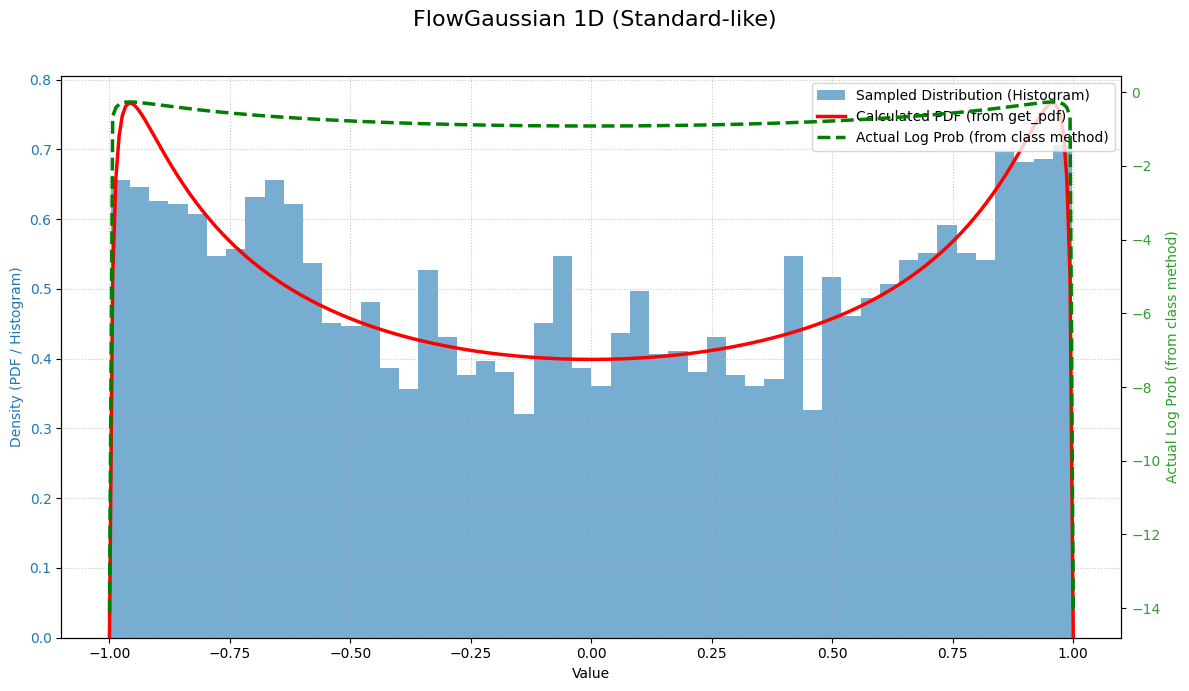

gaussian_log_prob (5, 1, 1) (5, 2) None
means_all (5, 1, 1) scales_all (5, 1, 1) clipped_actions (5, 1, 1)
Log probabilities for first 5 samples (using gaussian_log_prob): [-0.79572192 -0.91410375 -0.33040346 -0.9019606  -0.73944085]
Entropy (Standard-like): 0.6671027622968171

FlowGaussian 1D (Random: mean=0.51, scale=0.73)
gaussian_log_prob (300, 1, 1) (300, 2) None
means_all (300, 1, 1) scales_all (300, 1, 1) clipped_actions (300, 1, 1)


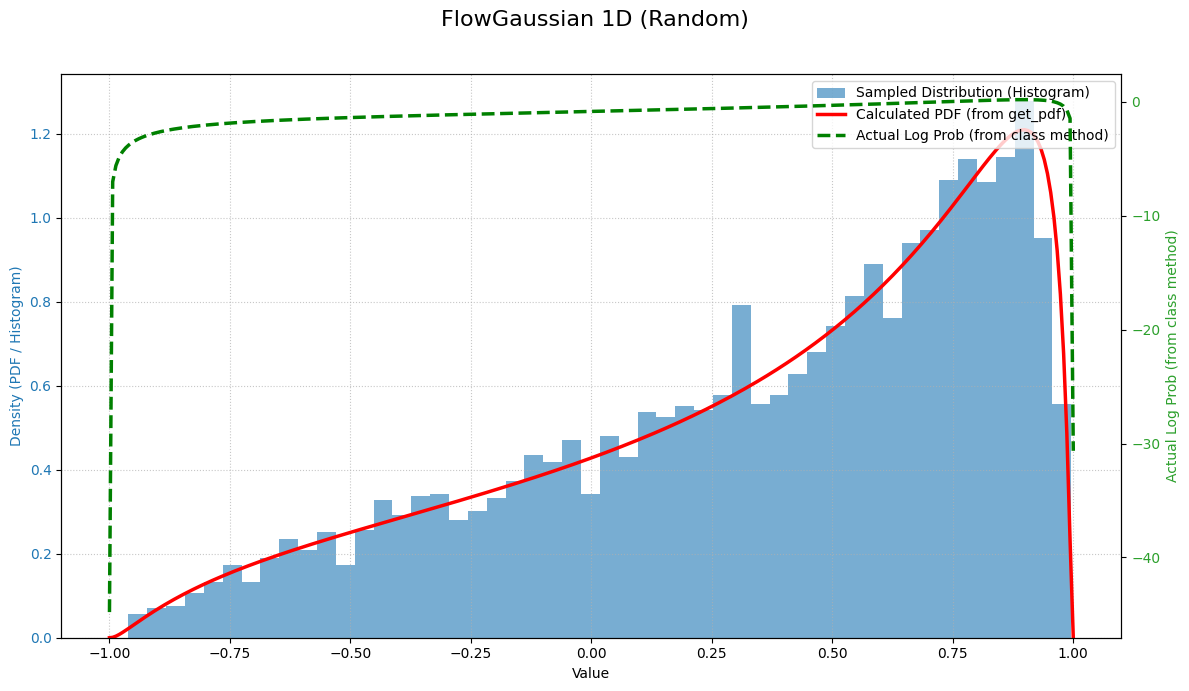


FlowGaussian 1D Entropy Test (Maximizing: mean=0.0, scale=10.0)
Entropy (Maximizing): -5.669780234758227


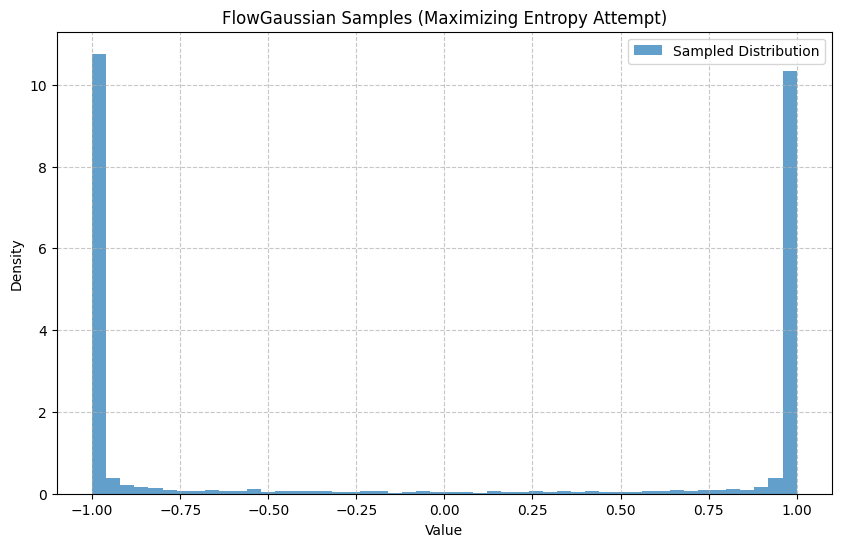


FlowGaussian 1D Entropy Test (Minimizing: mean=0.0, scale=0.01)
Entropy (Minimizing): -3.09859493219743


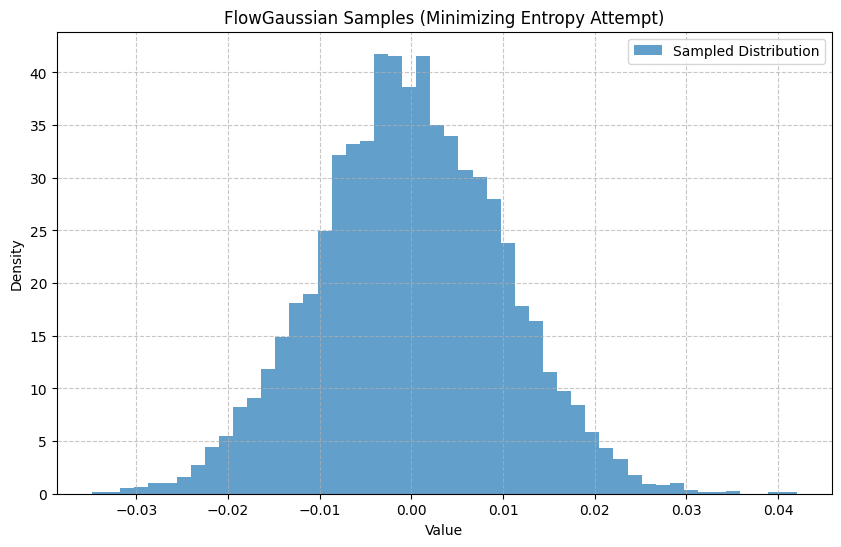


FlowGaussian 2D (Random: means=[[ 0.92213732 -0.75977286]], scales=[[0.93595502 1.25397551]])


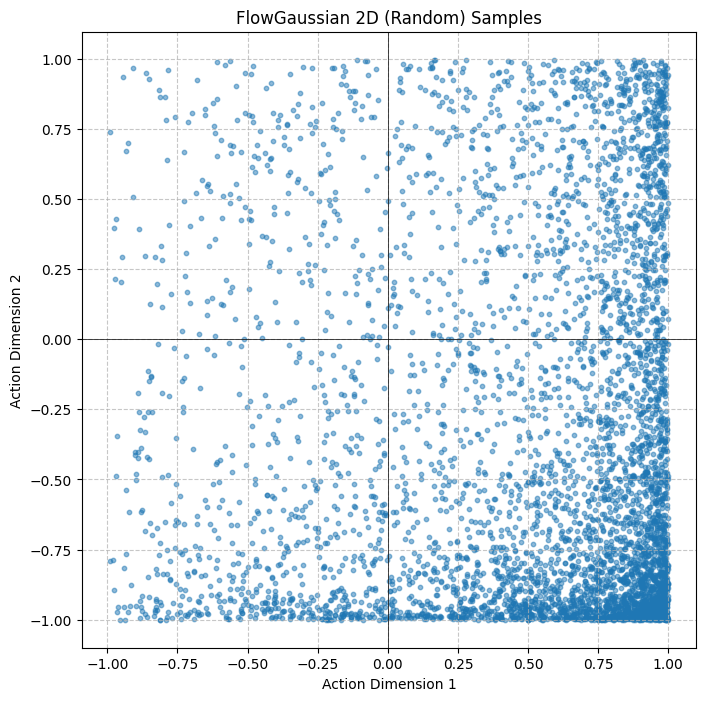

gaussian_log_prob (1, 1, 2) (1, 4) None
means_all (1, 1, 2) scales_all (1, 1, 2) clipped_actions (1, 1, 2)
Log probability for one 2D sample (using gaussian_log_prob): [1.2075735]
Entropy (MC) for 2D distribution: 0.3766476060348377


--- Testing NormFlowAgent ---

NormFlowAgent 1D (Standard-like: loc=[0.], raw_L00 to target std_dev=1.0 is 0.54)
Sampled 5000 points. First 5: [ 0.75452744  0.82592865 -0.35346271  0.11035586 -0.10037532]


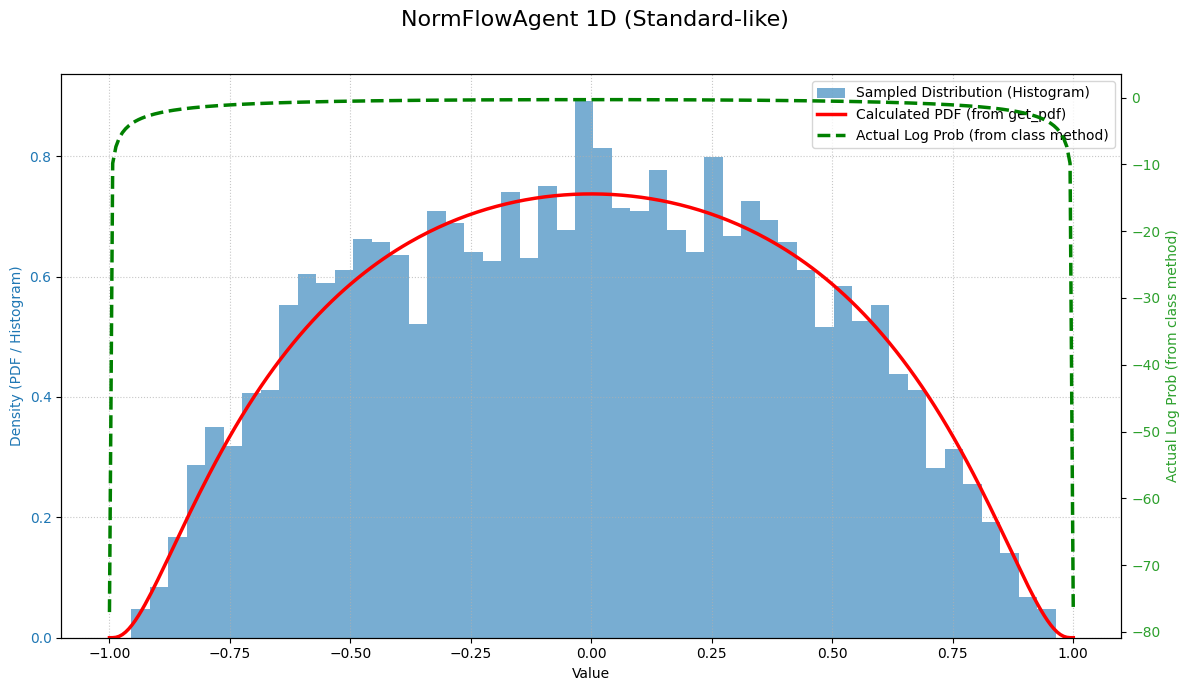

Log probability for first 1 sample(s) (using gaussian_log_prob): [-1.11356998]
Entropy (Standard-like): 0.5392483858151289

NormFlowAgent 1D (Random: loc=[-0.42172089], raw_tril_diag_input=[0.38033992])


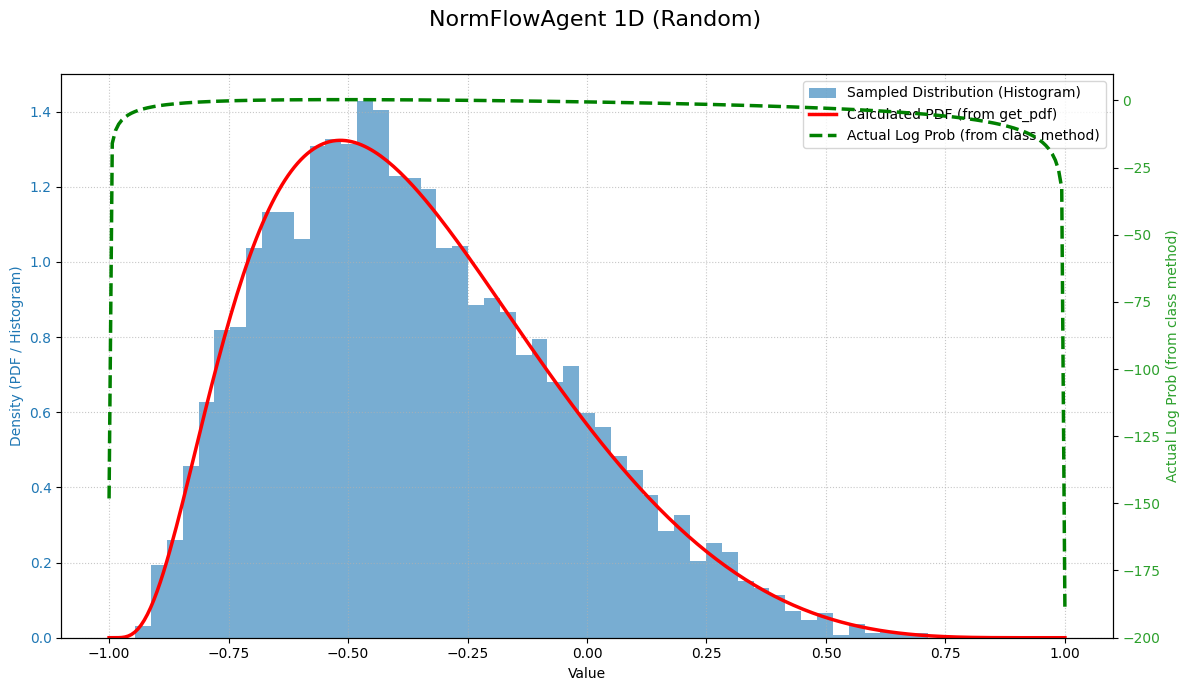


NormFlowAgent 1D Entropy Test (Maximizing: loc=[0.], raw_L00 to target std_dev=10.0)
Entropy (Maximizing): -4.750447296340272


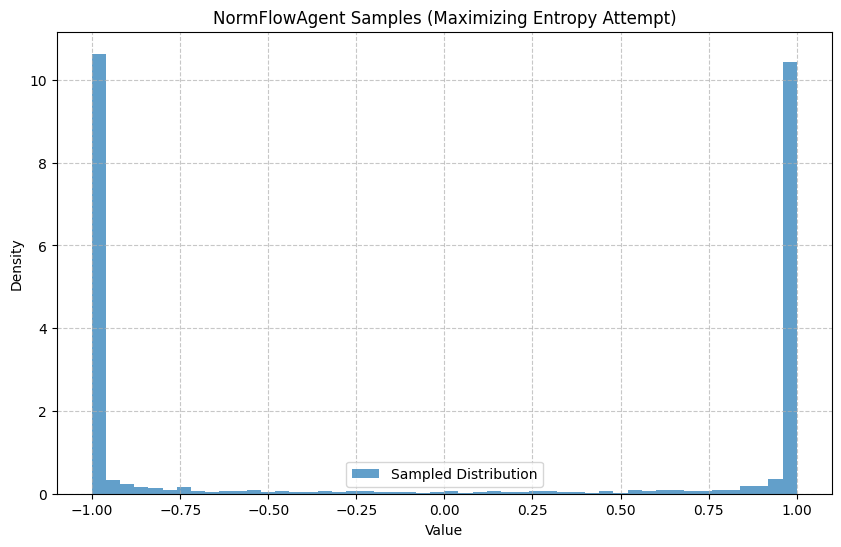


NormFlowAgent 1D Entropy Test (Minimizing: loc=[0.], raw_L00 to target std_dev=0.01)
Entropy (Minimizing): -1.3298475242312355


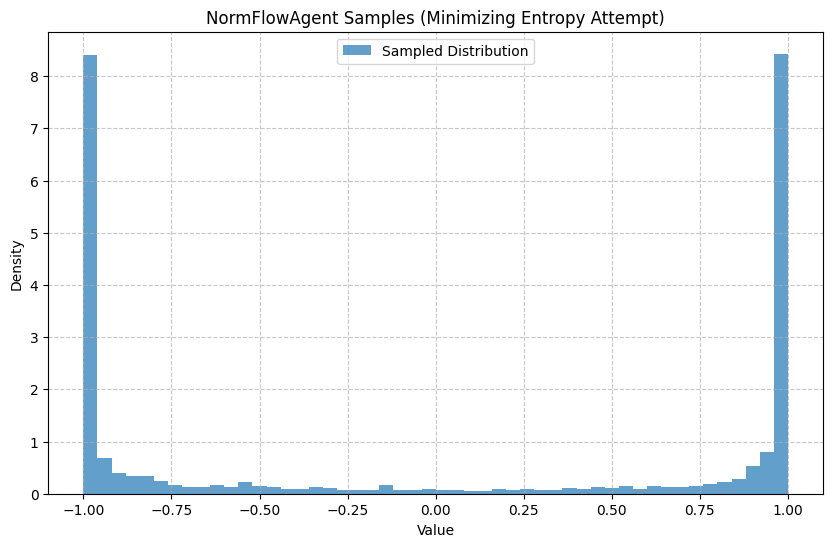


NormFlowAgent 2D (Random: loc=[-0.36656436 -0.03027168], raw_tril_values_input=[-0.00442415 -0.07249381  0.16492362])


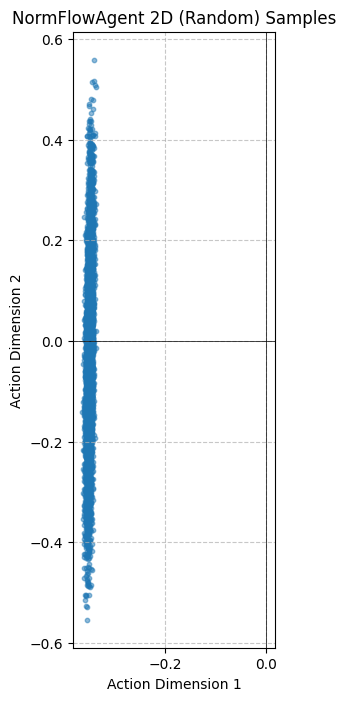

Log probability for one 2D sample (using gaussian_log_prob): [3.82693538]
Entropy (MC) for 2D distribution: -4.308652149908648


Final Note: Visual check of PDF vs samples and the shape of 'Actual Log Prob (from class method)' is key.
For entropy, compare values from 'Maximizing' and 'Minimizing' scenarios. Higher entropy is expected for 'Maximizing'.


In [45]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import equinox as eqx # Flowjax flows are often eqx.Modules
from flowjax.distributions import MultivariateNormal, Transformed, Normal
from flowjax.bijections import Tanh, Chain, AbstractBijection

# Seed for reproducibility (using newer jax.random.key)
key = jax.random.key(0)

# Epsilon constant (assuming it's used by the imported classes, e.g., for clipping or jitter)
EPSILON = 1e-6

#-------------------------------------------------------------------------------
# Class Imports
#-------------------------------------------------------------------------------
# IMPORTANT: This notebook assumes that the following classes are accessible in your Python environment.
# You might need to adjust your PYTHONPATH or ensure your package is installed.

FlowGaussian = None
NormFlowAgent = None
try:
    # Attempt to import the user's actual classes
    from src.agents.ppo_dic_inherits.inh_agents.flow_full import FlowGaussian
    from src.agents.ppo_dic_inherits.inh_agents.norm_flow_agent import NormFlowAgent
    # SamplingImplBaseJax is expected to be the base class and imported correctly by the above.
    print("Successfully imported user-defined FlowGaussian and NormFlowAgent.")
    if not callable(FlowGaussian) or not callable(NormFlowAgent):
        # This handles cases where the import path is technically valid but points to non-callable objects
        # or if the modules exist but the classes are not defined/exported correctly.
        print("Warning: Imported names FlowGaussian or NormFlowAgent are not callable. Check class definitions and exports.")
        FlowGaussian = None # Reset to ensure fallback or error occurs if not truly available
        NormFlowAgent = None
except ImportError as e:
    print(f"CRITICAL ERROR: Could not import user-defined classes: {e}")
    print("Please ensure 'src' is in your PYTHONPATH and the module/class names are correct.")
    print("The notebook cannot proceed effectively without these classes.")
    print("Subsequent code relying on these classes will likely fail.")
except Exception as e_general: # Catch other potential issues during import
    print(f"An unexpected error occurred during class import: {e_general}")
    FlowGaussian = None
    NormFlowAgent = None

#-------------------------------------------------------------------------------
# Helper Functions for Plotting
#-------------------------------------------------------------------------------

def plot_samples_vs_pdf(samples, pdf_values, x_range, title, bins=50, 
                        actual_log_prob_values=None, actual_log_prob_label="Actual Log Prob (from class method)"):
    fig, ax1 = plt.subplots(figsize=(12, 7))
    ax1.hist(samples.flatten(), bins=bins, density=True, alpha=0.6, label='Sampled Distribution (Histogram)', color='tab:blue')
    ax1.set_xlabel('Value')
    ax1.set_ylabel('Density (PDF / Histogram)', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    if pdf_values is not None and x_range is not None:
        ax1.plot(x_range, pdf_values, color='red', lw=2.5, label='Calculated PDF (from get_pdf)')
    handles1, labels1 = ax1.get_legend_handles_labels()
    if actual_log_prob_values is not None and x_range is not None:
        ax2 = ax1.twinx() 
        ax2.plot(x_range, actual_log_prob_values, color='green', linestyle='--', lw=2.5, label=actual_log_prob_label)
        ax2.set_ylabel(actual_log_prob_label, color='tab:green')
        ax2.tick_params(axis='y', labelcolor='tab:green')
        handles2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(handles1 + handles2, labels1 + labels2, loc='upper right')
    else:
        ax1.legend(handles1, labels1, loc='upper right')
    fig.suptitle(title, fontsize=16)
    ax1.grid(True, linestyle=':', alpha=0.7)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

def plot_histogram(samples, title, bins=50):
    """Simple histogram plot for visualizing distributions, e.g., for entropy tests."""
    plt.figure(figsize=(10, 6))
    plt.hist(samples.flatten(), bins=bins, density=True, alpha=0.7, label='Sampled Distribution')
    plt.title(title)
    plt.xlabel('Value')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

def plot_samples_2d(samples, title):
    if samples.shape[1] != 2:
        print("Can only plot 2D samples for this function.")
        if samples.shape[1] == 1:
             plt.hist(samples.flatten(), bins=50, density=True, alpha=0.7, label='Dim 1')
             plt.title(f"{title} - Marginal Dim 1")
             plt.show()
        return
    plt.figure(figsize=(8, 8))
    plt.scatter(samples[:, 0], samples[:, 1], alpha=0.5, s=10)
    plt.title(title)
    plt.xlabel('Action Dimension 1')
    plt.ylabel('Action Dimension 2')
    plt.axhline(0, color='black', lw=0.5)
    plt.axvline(0, color='black', lw=0.5)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.show()

#-------------------------------------------------------------------------------
# Test Configuration
#-------------------------------------------------------------------------------
num_samples_for_hist = 5000
x_eval_points_flat = jnp.linspace(-1 + EPSILON, 1 - EPSILON, 300) 
x_eval_points_reshaped = x_eval_points_flat[:, None] 

#-------------------------------------------------------------------------------
# Testing FlowGaussian
#-------------------------------------------------------------------------------
if FlowGaussian is not None and callable(FlowGaussian):
    print("--- Testing FlowGaussian ---")

    # --- Test Case 1: FlowGaussian, 1D, Standard-like parameters ---
    key, fg_key_s1, fg_key_lp1_curve, fg_key_lp1_pts, fg_key_e1 = jax.random.split(key, 5)
    action_dim_fg1 = 1
    std_mean_fg1 = 0.0
    std_scale_fg1 = 1.0 
    act_logits_fg1_single_dist_params = jnp.array([std_mean_fg1, std_scale_fg1])
    print(f"\nFlowGaussian 1D (Standard-like: mean={std_mean_fg1}, scale={std_scale_fg1})")

    fg_agent_b1_ad1 = FlowGaussian(1, action_dim_fg1) 
    pdf_values_fg1_std_batch = fg_agent_b1_ad1.get_pdf(act_logits_fg1_single_dist_params, None, x_eval_points_reshaped)
    pdf_values_fg1_std = pdf_values_fg1_std_batch[0]
    actions_for_log_prob_curve_fg1 = x_eval_points_reshaped.reshape(x_eval_points_reshaped.shape[0], 1, action_dim_fg1)
    act_logits_for_log_prob_curve_fg1 = jnp.tile(act_logits_fg1_single_dist_params, (x_eval_points_reshaped.shape[0], 1))
    actual_log_probs_curve_fg1_std = fg_agent_b1_ad1.gaussian_log_prob(actions_for_log_prob_curve_fg1, act_logits_for_log_prob_curve_fg1, None)

    fg_agent_bHist_ad1 = FlowGaussian(num_samples_for_hist, action_dim_fg1)
    act_logits_fg1_std_means_hist = jnp.full((num_samples_for_hist, action_dim_fg1), std_mean_fg1)
    act_logits_fg1_std_scales_hist = jnp.full((num_samples_for_hist, action_dim_fg1), std_scale_fg1)
    act_logits_fg1_std_for_hist = jnp.concatenate([act_logits_fg1_std_means_hist.flatten(), act_logits_fg1_std_scales_hist.flatten()])
    samples_fg1_std = fg_agent_bHist_ad1.sampling_differ(act_logits_fg1_std_for_hist, None, fg_key_s1, masks=jnp.array([num_samples_for_hist]))
    print(f"Sampled {samples_fg1_std.shape[0]} points for histogram. First 5: {samples_fg1_std[:5].flatten()}")
    plot_samples_vs_pdf(samples_fg1_std, pdf_values_fg1_std, x_eval_points_flat, 
                        "FlowGaussian 1D (Standard-like)", 
                        actual_log_prob_values=actual_log_probs_curve_fg1_std)

    num_test_points_fg1 = min(5, samples_fg1_std.shape[0])
    if num_test_points_fg1 > 0:
        test_actions_pts_fg1 = samples_fg1_std[:num_test_points_fg1].reshape(num_test_points_fg1, 1, action_dim_fg1)
        act_logits_pts_fg1 = jnp.tile(act_logits_fg1_single_dist_params, (num_test_points_fg1, 1))
        log_probs_pts_fg1_std = fg_agent_b1_ad1.gaussian_log_prob(test_actions_pts_fg1, act_logits_pts_fg1, None)
        print(f"Log probabilities for first {num_test_points_fg1} samples (using gaussian_log_prob): {log_probs_pts_fg1_std}")
    act_logits_entropy_fg1 = act_logits_fg1_single_dist_params.reshape(1, -1) 
    mask_entropy_fg1 = jnp.array([[1.0]]) 
    entropy_fg1_std_val = fg_agent_b1_ad1.entropy(act_logits_entropy_fg1, mask_entropy_fg1, None, fg_key_e1)
    print(f"Entropy (Standard-like): {entropy_fg1_std_val.item()}")

    # --- Test Case 2: FlowGaussian, 1D, Random parameters ---
    key, fg_key_rand_m, fg_key_rand_s, fg_key_rand_samp, fg_key_rand_lp_curve = jax.random.split(key, 5)
    rand_mean_fg1 = jax.random.uniform(fg_key_rand_m, minval=-1.5, maxval=1.5)
    rand_scale_fg1 = jax.random.uniform(fg_key_rand_s, minval=0.2, maxval=1.5) 
    act_logits_fg1_rand_single_dist_params = jnp.array([rand_mean_fg1.item(), rand_scale_fg1.item()])
    print(f"\nFlowGaussian 1D (Random: mean={rand_mean_fg1.item():.2f}, scale={rand_scale_fg1.item():.2f})")
    pdf_values_fg1_rand_batch = fg_agent_b1_ad1.get_pdf(act_logits_fg1_rand_single_dist_params, None, x_eval_points_reshaped)
    pdf_values_fg1_rand = pdf_values_fg1_rand_batch[0]
    actions_for_log_prob_curve_fg1_rand = x_eval_points_reshaped.reshape(x_eval_points_reshaped.shape[0], 1, action_dim_fg1)
    act_logits_for_log_prob_curve_fg1_rand = jnp.tile(act_logits_fg1_rand_single_dist_params, (x_eval_points_reshaped.shape[0], 1))
    actual_log_probs_curve_fg1_rand = fg_agent_b1_ad1.gaussian_log_prob(actions_for_log_prob_curve_fg1_rand, act_logits_for_log_prob_curve_fg1_rand, None)
    act_logits_fg1_rand_means_hist = jnp.full((num_samples_for_hist, action_dim_fg1), rand_mean_fg1.item())
    act_logits_fg1_rand_scales_hist = jnp.full((num_samples_for_hist, action_dim_fg1), rand_scale_fg1.item())
    act_logits_fg1_rand_for_hist = jnp.concatenate([act_logits_fg1_rand_means_hist.flatten(), act_logits_fg1_rand_scales_hist.flatten()])
    samples_fg1_rand = fg_agent_bHist_ad1.sampling_differ(act_logits_fg1_rand_for_hist, None, fg_key_rand_samp, masks=jnp.array([num_samples_for_hist]))
    plot_samples_vs_pdf(samples_fg1_rand, pdf_values_fg1_rand, x_eval_points_flat, 
                        "FlowGaussian 1D (Random)",
                        actual_log_prob_values=actual_log_probs_curve_fg1_rand)

    # --- Entropy Test: Maximizing (Near Uniform) for FlowGaussian ---
    key, fg_key_e_max_s, fg_key_e_max_e = jax.random.split(key, 3)
    mean_max_entropy_fg = 0.0
    scale_max_entropy_fg = 10.0 # Large scale for near-uniform after Tanh
    act_logits_max_entropy_fg = jnp.array([mean_max_entropy_fg, scale_max_entropy_fg])
    print(f"\nFlowGaussian 1D Entropy Test (Maximizing: mean={mean_max_entropy_fg}, scale={scale_max_entropy_fg})")
    entropy_max_fg = fg_agent_b1_ad1.entropy(act_logits_max_entropy_fg.reshape(1,-1), mask_entropy_fg1, None, fg_key_e_max_e)
    print(f"Entropy (Maximizing): {entropy_max_fg.item()}")
    # Visual check
    act_logits_max_means_hist = jnp.full((num_samples_for_hist, action_dim_fg1), mean_max_entropy_fg)
    act_logits_max_scales_hist = jnp.full((num_samples_for_hist, action_dim_fg1), scale_max_entropy_fg)
    act_logits_max_for_hist = jnp.concatenate([act_logits_max_means_hist.flatten(), act_logits_max_scales_hist.flatten()])
    samples_max_entropy_fg = fg_agent_bHist_ad1.sampling_differ(act_logits_max_for_hist, None, fg_key_e_max_s, masks=jnp.array([num_samples_for_hist]))
    plot_histogram(samples_max_entropy_fg, "FlowGaussian Samples (Maximizing Entropy Attempt)")

    # --- Entropy Test: Minimizing (Peaked) for FlowGaussian ---
    key, fg_key_e_min_s, fg_key_e_min_e = jax.random.split(key, 3)
    mean_min_entropy_fg = 0.0
    scale_min_entropy_fg = 0.01 # Small scale for peaked distribution
    act_logits_min_entropy_fg = jnp.array([mean_min_entropy_fg, scale_min_entropy_fg])
    print(f"\nFlowGaussian 1D Entropy Test (Minimizing: mean={mean_min_entropy_fg}, scale={scale_min_entropy_fg})")
    entropy_min_fg = fg_agent_b1_ad1.entropy(act_logits_min_entropy_fg.reshape(1,-1), mask_entropy_fg1, None, fg_key_e_min_e)
    print(f"Entropy (Minimizing): {entropy_min_fg.item()}")
    # Visual check
    act_logits_min_means_hist = jnp.full((num_samples_for_hist, action_dim_fg1), mean_min_entropy_fg)
    act_logits_min_scales_hist = jnp.full((num_samples_for_hist, action_dim_fg1), scale_min_entropy_fg)
    act_logits_min_for_hist = jnp.concatenate([act_logits_min_means_hist.flatten(), act_logits_min_scales_hist.flatten()])
    samples_min_entropy_fg = fg_agent_bHist_ad1.sampling_differ(act_logits_min_for_hist, None, fg_key_e_min_s, masks=jnp.array([num_samples_for_hist]))
    plot_histogram(samples_min_entropy_fg, "FlowGaussian Samples (Minimizing Entropy Attempt)")
    
    # --- Test Case 3: FlowGaussian, 2D, Random parameters (condensed) ---
    key, fg_key_2d_m, fg_key_2d_s, fg_key_2d_samp, fg_key_2d_lp_pts, fg_key_2d_e = jax.random.split(key, 6)
    action_dim_fg2 = 2
    means_fg2_rand_single = jax.random.uniform(fg_key_2d_m, shape=(1, action_dim_fg2), minval=-1.0, maxval=1.0)
    scales_fg2_rand_single = jax.random.uniform(fg_key_2d_s, shape=(1, action_dim_fg2), minval=0.2, maxval=1.5)
    act_logits_fg2_single_dist_params = jnp.concatenate([means_fg2_rand_single.flatten(), scales_fg2_rand_single.flatten()])
    print(f"\nFlowGaussian 2D (Random: means={means_fg2_rand_single}, scales={scales_fg2_rand_single})")
    fg_agent_bHist_ad2 = FlowGaussian(num_samples_for_hist, action_dim_fg2)
    act_logits_fg2_rand_means_hist = jnp.tile(means_fg2_rand_single, (num_samples_for_hist, 1))
    act_logits_fg2_rand_scales_hist = jnp.tile(scales_fg2_rand_single, (num_samples_for_hist, 1))
    act_logits_fg2_rand_for_hist = jnp.concatenate([act_logits_fg2_rand_means_hist.flatten(), act_logits_fg2_rand_scales_hist.flatten()])
    samples_fg2_rand = fg_agent_bHist_ad2.sampling_differ(act_logits_fg2_rand_for_hist, None, fg_key_2d_samp, masks=jnp.array([num_samples_for_hist]))
    plot_samples_2d(samples_fg2_rand, "FlowGaussian 2D (Random) Samples")
    fg_agent_b1_ad2 = FlowGaussian(1, action_dim_fg2) 
    num_test_points_fg2 = min(1, samples_fg2_rand.shape[0])
    if num_test_points_fg2 > 0:
        test_actions_pts_fg2 = samples_fg2_rand[:num_test_points_fg2].reshape(num_test_points_fg2, 1, action_dim_fg2)
        act_logits_pts_fg2 = jnp.tile(act_logits_fg2_single_dist_params, (num_test_points_fg2, 1))
        log_probs_pts_fg2_rand = fg_agent_b1_ad2.gaussian_log_prob(test_actions_pts_fg2, act_logits_pts_fg2, None)
        print(f"Log probability for one 2D sample (using gaussian_log_prob): {log_probs_pts_fg2_rand}")
    act_logits_entropy_fg2 = act_logits_fg2_single_dist_params.reshape(1, -1)
    mask_entropy_fg2 = jnp.array([[1.0]])
    entropy_fg2_rand = fg_agent_b1_ad2.entropy(act_logits_entropy_fg2, mask_entropy_fg2, None, fg_key_2d_e)
    print(f"Entropy (MC) for 2D distribution: {entropy_fg2_rand.item()}")
else:
    print("FlowGaussian class not imported/defined or not callable. Skipping FlowGaussian tests.")

#-------------------------------------------------------------------------------
# Testing NormFlowAgent
#-------------------------------------------------------------------------------
if NormFlowAgent is not None and callable(NormFlowAgent):
    print("\n\n--- Testing NormFlowAgent ---")
    action_dim_nfa1 = 1 # For 1D tests
    nfa_agent_ad1_hist = NormFlowAgent(num_samples_for_hist, action_dim_nfa1) # For sampling
    nfa_agent_ad1_single = NormFlowAgent(1, action_dim_nfa1) # For single operations like entropy on one dist def

    # --- Test Case 1: NormFlowAgent, 1D, Standard-like parameters ---
    key, nfa_key_s1, nfa_key_lp1_curve, nfa_key_lp1_pts, nfa_key_e1 = jax.random.split(key, 5)
    std_loc_nfa1 = jnp.array([0.0])
    target_std_dev_nfa1 = 1.0
    # For NormFlowAgent, L_diag_processed = softplus(L_diag_raw) + 1e-4
    # We want L_diag_processed = target_std_dev_nfa1
    softplus_val_nfa1 = target_std_dev_nfa1 - 1e-4
    std_raw_L00_nfa1 = jnp.log(jnp.exp(softplus_val_nfa1) - 1) if softplus_val_nfa1 > 0 else -10.0 # Avoid log(neg)
    act_logits_nfa1_single_dist_params = jnp.concatenate([std_loc_nfa1, jnp.array([std_raw_L00_nfa1])])
    print(f"\nNormFlowAgent 1D (Standard-like: loc={std_loc_nfa1}, raw_L00 to target std_dev={target_std_dev_nfa1} is {std_raw_L00_nfa1:.2f})")
    
    samples_nfa1_std = nfa_agent_ad1_hist.sampling_differ(act_logits_nfa1_single_dist_params, None, nfa_key_s1, mask_threshold_array=jnp.array([num_samples_for_hist]))
    print(f"Sampled {samples_nfa1_std.shape[0]} points. First 5: {samples_nfa1_std[:5].flatten()}")
    pdf_values_nfa1_std = nfa_agent_ad1_hist.get_pdf(act_logits_nfa1_single_dist_params, None, x_eval_points_reshaped)
    actions_for_log_prob_curve_nfa1 = x_eval_points_reshaped.reshape(x_eval_points_reshaped.shape[0], 1, action_dim_nfa1)
    act_logits_for_log_prob_curve_nfa1 = jnp.tile(act_logits_nfa1_single_dist_params, (x_eval_points_reshaped.shape[0], 1))
    actual_log_probs_curve_nfa1_std = nfa_agent_ad1_hist.gaussian_log_prob(actions_for_log_prob_curve_nfa1, act_logits_for_log_prob_curve_nfa1, None)
    plot_samples_vs_pdf(samples_nfa1_std, pdf_values_nfa1_std, x_eval_points_flat,
                        "NormFlowAgent 1D (Standard-like)",
                        actual_log_prob_values=actual_log_probs_curve_nfa1_std)

    num_test_points_nfa1 = min(1, samples_nfa1_std.shape[0])
    if num_test_points_nfa1 > 0:
        test_actions_pts_nfa1 = samples_nfa1_std[:num_test_points_nfa1].reshape(num_test_points_nfa1, 1, action_dim_nfa1)
        act_logits_pts_nfa1 = jnp.tile(act_logits_nfa1_single_dist_params, (num_test_points_nfa1, 1))
        log_probs_pts_nfa1_std = nfa_agent_ad1_hist.gaussian_log_prob(test_actions_pts_nfa1, act_logits_pts_nfa1, None)
        print(f"Log probability for first {num_test_points_nfa1} sample(s) (using gaussian_log_prob): {log_probs_pts_nfa1_std}")
    act_logits_entropy_nfa1 = act_logits_nfa1_single_dist_params.reshape(1, -1)
    mask_entropy_nfa1 = jnp.array([[1.0]])
    entropy_nfa1_std_val = nfa_agent_ad1_single.entropy(act_logits_entropy_nfa1, mask_entropy_nfa1, None, nfa_key_e1) # Use agent with batch_size=1 for entropy of single def
    print(f"Entropy (Standard-like): {entropy_nfa1_std_val.item()}")

    # --- Test Case 2: NormFlowAgent, 1D, Random parameters (condensed) ---
    key, nfa_key_rand_p, nfa_key_rand_s, nfa_key_rand_lp_curve = jax.random.split(key, 4)
    param_dim_nfa1 = action_dim_nfa1 + action_dim_nfa1 * (action_dim_nfa1 + 1) // 2
    act_logits_nfa1_rand_single_dist_params = jax.random.uniform(nfa_key_rand_p, shape=(param_dim_nfa1,), minval=-1.0, maxval=1.0)
    loc_rand, tril_rand = act_logits_nfa1_rand_single_dist_params[:action_dim_nfa1], act_logits_nfa1_rand_single_dist_params[action_dim_nfa1:]
    print(f"\nNormFlowAgent 1D (Random: loc={loc_rand}, raw_tril_diag_input={tril_rand})")
    samples_nfa1_rand = nfa_agent_ad1_hist.sampling_differ(act_logits_nfa1_rand_single_dist_params, None, nfa_key_rand_s, mask_threshold_array=jnp.array([num_samples_for_hist]))
    pdf_values_nfa1_rand = nfa_agent_ad1_hist.get_pdf(act_logits_nfa1_rand_single_dist_params, None, x_eval_points_reshaped)
    actions_for_log_prob_curve_nfa1_rand = x_eval_points_reshaped.reshape(x_eval_points_reshaped.shape[0], 1, action_dim_nfa1)
    act_logits_for_log_prob_curve_nfa1_rand = jnp.tile(act_logits_nfa1_rand_single_dist_params, (x_eval_points_reshaped.shape[0], 1))
    actual_log_probs_curve_nfa1_rand = nfa_agent_ad1_hist.gaussian_log_prob(actions_for_log_prob_curve_nfa1_rand, act_logits_for_log_prob_curve_nfa1_rand, None)
    plot_samples_vs_pdf(samples_nfa1_rand, pdf_values_nfa1_rand, x_eval_points_flat,
                        "NormFlowAgent 1D (Random)",
                        actual_log_prob_values=actual_log_probs_curve_nfa1_rand)

    # --- Entropy Test: Maximizing (Near Uniform) for NormFlowAgent ---
    key, nfa_key_e_max_s, nfa_key_e_max_e = jax.random.split(key, 3)
    loc_max_entropy_nfa = jnp.array([0.0])
    target_std_dev_max_nfa = 10.0
    softplus_val_max_nfa = target_std_dev_max_nfa - 1e-4
    raw_L00_max_entropy_nfa = jnp.log(jnp.exp(softplus_val_max_nfa) - 1) if softplus_val_max_nfa > 0 else -10.0
    act_logits_max_entropy_nfa = jnp.concatenate([loc_max_entropy_nfa, jnp.array([raw_L00_max_entropy_nfa])])
    print(f"\nNormFlowAgent 1D Entropy Test (Maximizing: loc={loc_max_entropy_nfa}, raw_L00 to target std_dev={target_std_dev_max_nfa})")
    entropy_max_nfa = nfa_agent_ad1_single.entropy(act_logits_max_entropy_nfa.reshape(1,-1), mask_entropy_nfa1, None, nfa_key_e_max_e)
    print(f"Entropy (Maximizing): {entropy_max_nfa.item()}")
    samples_max_entropy_nfa = nfa_agent_ad1_hist.sampling_differ(act_logits_max_entropy_nfa, None, nfa_key_e_max_s, mask_threshold_array=jnp.array([num_samples_for_hist]))
    plot_histogram(samples_max_entropy_nfa, "NormFlowAgent Samples (Maximizing Entropy Attempt)")

    # --- Entropy Test: Minimizing (Peaked) for NormFlowAgent ---
    key, nfa_key_e_min_s, nfa_key_e_min_e = jax.random.split(key, 3)
    loc_min_entropy_nfa = jnp.array([0.0])
    target_std_dev_min_nfa = 0.01
    softplus_val_min_nfa = target_std_dev_min_nfa - 1e-4
    raw_L00_min_entropy_nfa = jnp.log(jnp.exp(softplus_val_min_nfa) - 1) if softplus_val_min_nfa > 0 else -20.0 # Use a very small raw for very small std
    act_logits_min_entropy_nfa = jnp.concatenate([loc_min_entropy_nfa, jnp.array([raw_L00_min_entropy_nfa])])
    print(f"\nNormFlowAgent 1D Entropy Test (Minimizing: loc={loc_min_entropy_nfa}, raw_L00 to target std_dev={target_std_dev_min_nfa})")
    entropy_min_nfa = nfa_agent_ad1_single.entropy(act_logits_min_entropy_nfa.reshape(1,-1), mask_entropy_nfa1, None, nfa_key_e_min_e)
    print(f"Entropy (Minimizing): {entropy_min_nfa.item()}")
    samples_min_entropy_nfa = nfa_agent_ad1_hist.sampling_differ(act_logits_min_entropy_nfa, None, nfa_key_e_min_s, mask_threshold_array=jnp.array([num_samples_for_hist]))
    plot_histogram(samples_min_entropy_nfa, "NormFlowAgent Samples (Minimizing Entropy Attempt)")

    # --- Test Case 3: NormFlowAgent, 2D, Random parameters (condensed) ---
    key, nfa_key_2d_p, nfa_key_2d_s, nfa_key_2d_lp_pts, nfa_key_2d_e = jax.random.split(key, 5)
    action_dim_nfa2 = 2
    nfa_agent_ad2_hist = NormFlowAgent(num_samples_for_hist, action_dim_nfa2)
    nfa_agent_ad2_single = NormFlowAgent(1, action_dim_nfa2)
    param_dim_nfa2 = action_dim_nfa2 + action_dim_nfa2 * (action_dim_nfa2 + 1) // 2
    act_logits_nfa2_single_dist_params = jax.random.uniform(nfa_key_2d_p, shape=(param_dim_nfa2,), minval=-0.5, maxval=0.5) 
    loc_nfa2_rand = act_logits_nfa2_single_dist_params[:action_dim_nfa2]
    tril_vals_nfa2_rand = act_logits_nfa2_single_dist_params[action_dim_nfa2:]
    print(f"\nNormFlowAgent 2D (Random: loc={loc_nfa2_rand}, raw_tril_values_input={tril_vals_nfa2_rand})")
    samples_nfa2_rand = nfa_agent_ad2_hist.sampling_differ(act_logits_nfa2_single_dist_params, None, nfa_key_2d_s, mask_threshold_array=jnp.array([num_samples_for_hist]))
    plot_samples_2d(samples_nfa2_rand, "NormFlowAgent 2D (Random) Samples")
    num_test_points_nfa2 = min(1, samples_nfa2_rand.shape[0])
    if num_test_points_nfa2 > 0:
        test_actions_pts_nfa2 = samples_nfa2_rand[:num_test_points_nfa2].reshape(num_test_points_nfa2, 1, action_dim_nfa2)
        act_logits_pts_nfa2 = jnp.tile(act_logits_nfa2_single_dist_params, (num_test_points_nfa2, 1))
        log_probs_pts_nfa2_rand = nfa_agent_ad2_hist.gaussian_log_prob(test_actions_pts_nfa2, act_logits_pts_nfa2, None)
        print(f"Log probability for one 2D sample (using gaussian_log_prob): {log_probs_pts_nfa2_rand}")
    act_logits_entropy_nfa2 = act_logits_nfa2_single_dist_params.reshape(1, -1)
    mask_entropy_nfa2 = jnp.array([[1.0]])
    entropy_nfa2_rand = nfa_agent_ad2_single.entropy(act_logits_entropy_nfa2, mask_entropy_nfa2, None, nfa_key_2d_e)
    print(f"Entropy (MC) for 2D distribution: {entropy_nfa2_rand.item()}")
else:
    print("NormFlowAgent class not imported/defined or not callable. Skipping NormFlowAgent tests.")

print("\n\nFinal Note: Visual check of PDF vs samples and the shape of 'Actual Log Prob (from class method)' is key.")
print("For entropy, compare values from 'Maximizing' and 'Minimizing' scenarios. Higher entropy is expected for 'Maximizing'.")



--- 1. Verifying generate_mvn_params ---
Input act_logits_one_dist: [0.  0.2]
Parsed base distribution loc: [0.]
Parsed base distribution covariance: [[0.04]]
Parsed base distribution std_dev: [0.2]
------------------------------
--- 3. Sampling Actions ---
Shape of generated samples: (5000, 1)
Shape of valid samples (after filtering potential padding): (5000, 1)
------------------------------
--- 4. Calculating PDF ---
Shape of PDF values from agent.get_pdf: (500,)
Max absolute difference between agent's PDF and manually calculated PDF: 0.000000e+00
------------------------------
--- 5. Calculating Log Probability Curve ---
Max absolute difference between manual log_prob curve and log(agent's PDF): 4.333542e+02
------------------------------
--- 6. Calculating Log Probability for Individual Samples ---
Shape of log_probs_of_samples: (5000,)
------------------------------
--- 7. Plotting Results ---


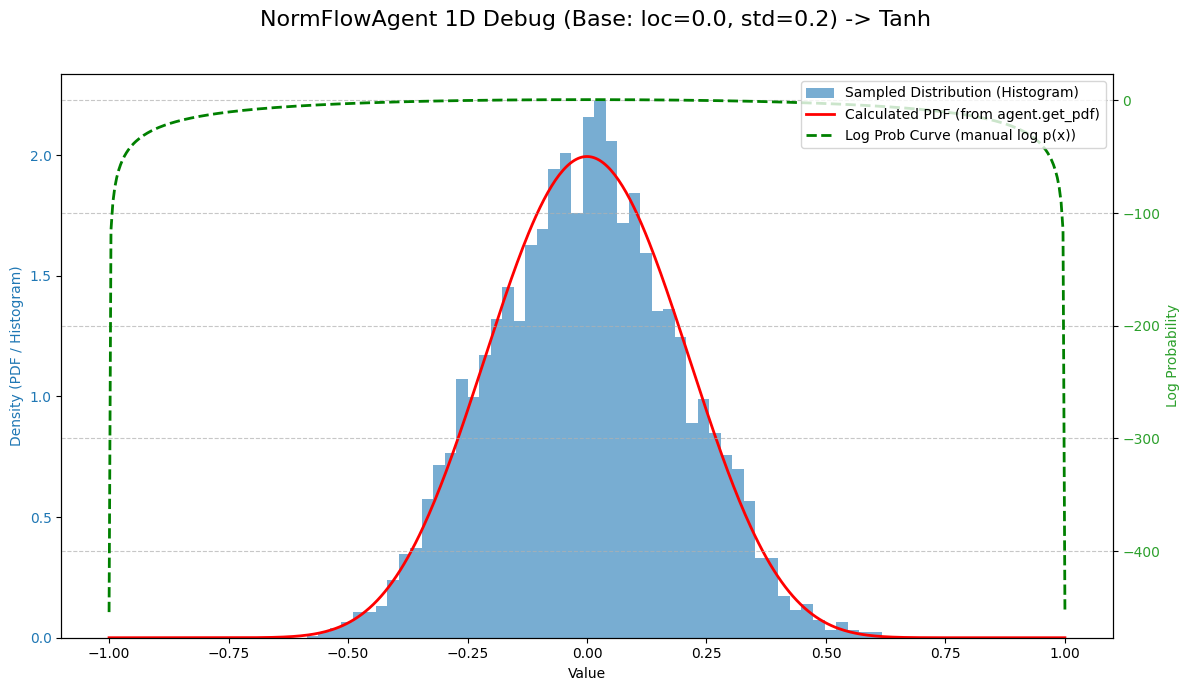


--- Debugging Notes ---
1. Check if 'Parsed base distribution loc/covariance' are as expected from ACT_LOGITS_ONE_DIST.
2. The histogram (blue) should align well with the PDF curve (red).
3. The Log Prob Curve (green dashed) should reflect the shape of the PDF (higher where PDF is higher).
4. Max absolute differences reported for PDF and Log Prob curves should be very small (e.g., < 1e-5) if implementations are consistent.

If the plot from this script looks consistent, but your training plot does not:
- The `act_logits` being used during training for sampling vs. log_prob calculation might differ.
- The `flow_object` parameter might be handled differently in training vs. plotting.
- The way `agent.gaussian_log_prob` is used/interpreted in your training loop might be the source of confusion, especially its sum over the time/sample axis.
  The green line in your original plot, if it's truly from `agent.gaussian_log_prob`, would represent something different than a simple `log p(x)` cur

In [ ]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import equinox as eqx # Not strictly needed for this script if flow_object is None, but good for context

# Assuming your NormFlowAgent class is accessible.
# If the notebook is in the same directory as a `src` folder, this might work:
# import sys
# sys.path.append('..') # Or the correct path to the root of your project
from src.agents.ppo_dic_inherits.inh_agents.norm_flow_agent import NormFlowAgent

# For flowjax components if we were to use them directly (for deeper debugging)
from flowjax.distributions import MultivariateNormal, Transformed
from flowjax.bijections import Tanh


# --- Configuration for the Debugging Script ---
ACTION_DIM = 1
MAX_BATCH_SIZE_SAMPLING = 5000  # Number of samples to draw for the histogram
KEY_SEED = 42

# Define fixed actor logits for a single 1D distribution.
# For 1D: act_logits = [mean_base, L_00_base]
# L_00_base is the single element of the Cholesky factor of the covariance.
# So, variance_base = L_00_base^2, and std_dev_base = |L_00_base|.
# Let's try to replicate a standard normal (mean=0, std=1) as the base, then Tanh transformed.
ACT_LOGITS_ONE_DIST = jnp.array([0.0, 0.2]) # Base: loc=0.0, std=1.0

# --- Instantiate the Agent ---
agent = NormFlowAgent(
    max_batch=MAX_BATCH_SIZE_SAMPLING, # For its internal self.batch_size used in sampling_differ
    action_dim=ACTION_DIM,
    sampling_distribution=1 # Default value
)

# --- 1. Verify Parameter Parsing (`generate_mvn_params`) ---
print("--- 1. Verifying generate_mvn_params ---")
loc_base, cov_base = agent.generate_mvn_params(ACT_LOGITS_ONE_DIST)
std_dev_base = jnp.sqrt(jnp.diag(cov_base))
print(f"Input act_logits_one_dist: {ACT_LOGITS_ONE_DIST}")
print(f"Parsed base distribution loc: {loc_base}")
print(f"Parsed base distribution covariance: {cov_base}")
print(f"Parsed base distribution std_dev: {std_dev_base}")
print("-" * 30)

# --- 2. Define the Distribution Explicitly (for cross-checking) ---
# This is what the agent should be doing internally.
# We use flow_object = None, so only Tanh transformation is applied.
base_dist_manual = MultivariateNormal(loc=loc_base, covariance=cov_base)
final_bijection_manual = agent._get_final_bijection(flow_object=None) # Should be just Tanh
final_dist_manual = Transformed(base_dist_manual, final_bijection_manual)

# --- 3. Sample Actions (`sampling_differ`) ---
print("--- 3. Sampling Actions ---")
key = jax.random.key(KEY_SEED)
sampling_key, entropy_key = jax.random.split(key)

# `sampling_differ` expects act_logits_one_dist, flow_object, key, mask_threshold_array
# mask_threshold_array determines how many of the self.batch_size samples are valid.
# For debugging, let's ensure all samples are used.
# The agent's self.batch_size is MAX_BATCH_SIZE_SAMPLING.
mask_threshold = jnp.array([MAX_BATCH_SIZE_SAMPLING])

# Note: `agent.sampling_differ` is designed for one distribution's logits.
# It internally samples `agent.batch_size` times.
samples = agent.sampling_differ(
    act_logits_one_dist=ACT_LOGITS_ONE_DIST,
    flow_object=None, # As per "Standard-like" and comments
    key=sampling_key,
    mask_threshold_array=mask_threshold
)
# samples shape should be (MAX_BATCH_SIZE_SAMPLING, ACTION_DIM)
print(f"Shape of generated samples: {samples.shape}")
# Filter out any padding values if necessary, though with mask_threshold = MAX_BATCH_SIZE_SAMPLING,
# there shouldn't be any padding.
samples_valid = samples[samples[:, 0] != -2.0] # Assuming -2.0 is the pad_value
print(f"Shape of valid samples (after filtering potential padding): {samples_valid.shape}")
print("-" * 30)

# --- 4. Calculate PDF (`get_pdf`) ---
print("--- 4. Calculating PDF ---")
# Define x_values for plotting the PDF and log_prob curve
# Avoid exact -1 and 1 for stability with Tanh inverse.
epsilon_plot = 1e-5
x_plot = jnp.linspace(-1 + epsilon_plot, 1 - epsilon_plot, 500).reshape(-1, ACTION_DIM)

pdf_values_from_agent = agent.get_pdf(
    act_logits_one_dist=ACT_LOGITS_ONE_DIST,
    flow_object=None,
    x_values=x_plot
)
print(f"Shape of PDF values from agent.get_pdf: {pdf_values_from_agent.shape}")

# For cross-checking with our manually constructed distribution:
pdf_values_manual = final_dist_manual.log_prob(x_plot)
pdf_values_manual = jnp.exp(pdf_values_manual)  # Convert log_prob to PDF
pdf_diff = jnp.abs(pdf_values_from_agent - pdf_values_manual).max()
print(f"Max absolute difference between agent's PDF and manually calculated PDF: {pdf_diff:.6e}")
print("-" * 30)

# --- 5. Calculate Log Probability (for the curve) ---
# The green dashed line in your plot is likely log p(x).
# We can get this from our `final_dist_manual` or by taking log of PDF.
print("--- 5. Calculating Log Probability Curve ---")
log_prob_curve_manual = final_dist_manual.log_prob(x_plot)
# Ensure x_plot is correctly shaped if action_dim > 1, here it's (num_points, 1)

# If agent.get_pdf correctly computes exp(final_dist.log_prob(x_values)),
# then log(agent.get_pdf(...)) should give the log_prob curve.
# Add a small epsilon to pdf_values to avoid log(0) if any PDF value is exactly zero.
log_prob_curve_from_agent_pdf = jnp.log(pdf_values_from_agent + 1e-9)

log_prob_curve_diff = jnp.abs(log_prob_curve_manual - log_prob_curve_from_agent_pdf).max()
print(f"Max absolute difference between manual log_prob curve and log(agent's PDF): {log_prob_curve_diff:.6e}")
print("-" * 30)

# --- 6. Calculate Log Probability for Individual Samples ---
# This is to check if log_prob(specific_sample) makes sense.
# Your `gaussian_log_prob` method has a specific batch structure and sums log_probs.
# For this debugging plot, we are interested in log p(s_i) for each sample s_i.
# We'll use `final_dist_manual.log_prob` for this.
print("--- 6. Calculating Log Probability for Individual Samples ---")
# Clip samples slightly if they are exactly -1 or 1, for atanh stability if not already handled by flowjax
samples_clipped_for_log_prob = jnp.clip(samples_valid, -1 + epsilon_plot, 1 - epsilon_plot)
log_probs_of_samples = final_dist_manual.log_prob(samples_clipped_for_log_prob)
print(f"Shape of log_probs_of_samples: {log_probs_of_samples.shape}")
print("-" * 30)


# --- 7. Visualization ---
print("--- 7. Plotting Results ---")
fig, ax1 = plt.subplots(figsize=(12, 7))

# Plot Histogram of samples
ax1.hist(samples_valid[:, 0], bins=50, density=True, alpha=0.6, label="Sampled Distribution (Histogram)", color="tab:blue")
ax1.set_xlabel("Value")
ax1.set_ylabel("Density (PDF / Histogram)", color="tab:blue")
ax1.tick_params(axis='y', labelcolor="tab:blue")

# Plot PDF from agent.get_pdf
ax1.plot(x_plot[:, 0], pdf_values_from_agent, color="red", linewidth=2, label="Calculated PDF (from agent.get_pdf)")
# ax1.plot(x_plot[:, 0], pdf_values_manual, color="orange", linestyle="--", linewidth=2, label="Calculated PDF (manual)")


# Create a second y-axis for the log probability
ax2 = ax1.twinx()
ax2.set_ylabel("Log Probability", color="tab:green")
ax2.tick_params(axis='y', labelcolor="tab:green")

# Plot Log Probability curve (log p(x))
ax2.plot(x_plot[:, 0], log_prob_curve_manual, color="green", linestyle="--", linewidth=2, label="Log Prob Curve (manual log p(x))")
# You can also plot log_prob_curve_from_agent_pdf to see if it matches
# ax2.plot(x_plot[:, 0], log_prob_curve_from_agent_pdf, color="lightgreen", linestyle=":", linewidth=2, label="Log Prob Curve (from log(agent.get_pdf))")


# Optional: Plot log_prob for individual samples (might be too noisy to see on the same plot as the curve)
# ax2.scatter(samples_valid[:,0], log_probs_of_samples, color='darkgreen', s=5, alpha=0.2, label='log_prob(individual sample)')


fig.suptitle(f"NormFlowAgent 1D Debug (Base: loc={loc_base[0]:.1f}, std={std_dev_base[0]:.1f}) -> Tanh", fontsize=16)
fig.legend(loc="upper right", bbox_to_anchor=(1,1), bbox_transform=ax1.transAxes)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust layout to make space for suptitle
plt.show()

print("\n--- Debugging Notes ---")
print("1. Check if 'Parsed base distribution loc/covariance' are as expected from ACT_LOGITS_ONE_DIST.")
print("2. The histogram (blue) should align well with the PDF curve (red).")
print("3. The Log Prob Curve (green dashed) should reflect the shape of the PDF (higher where PDF is higher).")
print("4. Max absolute differences reported for PDF and Log Prob curves should be very small (e.g., < 1e-5) if implementations are consistent.")
print("\nIf the plot from this script looks consistent, but your training plot does not:")
print("- The `act_logits` being used during training for sampling vs. log_prob calculation might differ.")
print("- The `flow_object` parameter might be handled differently in training vs. plotting.")
print("- The way `agent.gaussian_log_prob` is used/interpreted in your training loop might be the source of confusion, especially its sum over the time/sample axis.")
print("  The green line in your original plot, if it's truly from `agent.gaussian_log_prob`, would represent something different than a simple `log p(x)` curve due to that summation.")
